# EDA 8.1: Web Traffic Trend Analysis

This notebook analyzes web traffic trends, seasonality, spikes, and the observed relationship between traffic, Revenue, and AOV. Findings are descriptive signals for marketing interpretation, demand understanding, and forecast feature engineering, not causal claims.


## 1. Setup and File Discovery

Locate `web_traffic.csv`, `sales.csv`, and `orders.csv` anywhere under the current working directory. Missing files produce warnings and the notebook continues with available analysis.


In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['web_traffic.csv', 'sales.csv', 'orders.csv']

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)
for name, path in selected_paths.items():
    if path is None:
        warnings.warn(f'{name} was not found. The notebook will continue where possible.')


,file,found,path
0,web_traffic.csv,True,d:\Datathon-2026-Inlier\ai_eda\datathon-2026-r...
1,sales.csv,True,d:\Datathon-2026-Inlier\ai_eda\datathon-2026-r...
2,orders.csv,True,d:\Datathon-2026-Inlier\ai_eda\datathon-2026-r...


## 2. Load Web Traffic, Sales, and Orders Data

Load each available CSV safely with pandas and show the raw schemas.


In [2]:
def safe_read_csv(path, name):
    if path is None:
        return None
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f'Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns from {path}')
        return df
    except Exception as exc:
        warnings.warn(f'Could not load {name} from {path}: {exc}')
        return None

traffic_raw = safe_read_csv(selected_paths.get('web_traffic.csv'), 'web_traffic.csv')
sales_raw = safe_read_csv(selected_paths.get('sales.csv'), 'sales.csv')
orders_raw = safe_read_csv(selected_paths.get('orders.csv'), 'orders.csv')

schema_rows = []
for name, df in [('web_traffic.csv', traffic_raw), ('sales.csv', sales_raw), ('orders.csv', orders_raw)]:
    if df is not None:
        schema_rows.append({'file': name, 'rows': len(df), 'columns': len(df.columns), 'column_names': ', '.join(map(str, df.columns))})
schema_overview = pd.DataFrame(schema_rows)
display(schema_overview)


Loaded web_traffic.csv: 3,652 rows x 7 columns from d:\Datathon-2026-Inlier\ai_eda\datathon-2026-round-1\web_traffic.csv
Loaded sales.csv: 3,833 rows x 3 columns from d:\Datathon-2026-Inlier\ai_eda\datathon-2026-round-1\sales.csv
Loaded orders.csv: 646,945 rows x 8 columns from d:\Datathon-2026-Inlier\ai_eda\datathon-2026-round-1\orders.csv


,file,rows,columns,column_names
0,web_traffic.csv,3652,7,"date, sessions, unique_visitors, page_views, b..."
1,sales.csv,3833,3,"Date, Revenue, COGS"
2,orders.csv,646945,8,"order_id, order_date, customer_id, zip, order_..."


## 3. Identify Traffic, Date, Revenue, and Order Columns

Column matching normalizes case, spaces, punctuation, and underscores, then uses candidate names and keyword scoring to handle minor naming differences.


In [3]:
def column_lookup(df):
    if df is None:
        return {}
    return {normalize_name(c): c for c in df.columns}

def find_col(df, candidates=None, include_all=None, include_any=None, exclude_any=None, prefer_numeric=False):
    if df is None:
        return None
    candidates = candidates or []
    include_all = [normalize_name(x) for x in (include_all or [])]
    include_any = [normalize_name(x) for x in (include_any or [])]
    exclude_any = [normalize_name(x) for x in (exclude_any or [])]
    lookup = column_lookup(df)
    for cand in candidates:
        key = normalize_name(cand)
        if key in lookup:
            return lookup[key]
    scored = []
    for col in df.columns:
        key = normalize_name(col)
        if exclude_any and any(x in key for x in exclude_any):
            continue
        if include_all and not all(x in key for x in include_all):
            continue
        if include_any and not any(x in key for x in include_any):
            continue
        score = sum(3 for x in include_all if x in key) + sum(2 for x in include_any if x in key)
        if prefer_numeric and pd.api.types.is_numeric_dtype(df[col]):
            score += 1
        scored.append((score, len(key), col))
    if scored:
        scored.sort(key=lambda x: (-x[0], x[1], str(x[2])))
        return scored[0][2]
    return None

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

def infer_revenue_col(df):
    if df is None:
        return None
    direct = find_col(
        df,
        ['revenue', 'total_revenue', 'sales_amount', 'sales', 'net_sales', 'amount'],
        include_any=['revenue', 'salesamount', 'totalsales', 'netsales'],
        exclude_any=['cost', 'cogs', 'margin', 'profit', 'tax'],
        prefer_numeric=True,
    )
    if direct is not None:
        return direct
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) or to_num(df[c]).notna().mean() > 0.8]
    candidates = []
    for c in numeric_cols:
        key = normalize_name(c)
        if any(x in key for x in ['cost', 'cogs', 'margin', 'profit', 'tax', 'id']):
            continue
        vals = to_num(df[c])
        positive_share = (vals > 0).mean()
        candidates.append((positive_share, vals.abs().sum(skipna=True), c))
    if candidates:
        candidates.sort(key=lambda x: (-x[0], -x[1], str(x[2])))
        warnings.warn(f'Revenue column was not explicit; using likely numeric revenue column: {candidates[0][2]}')
        return candidates[0][2]
    return None

cols = {}
if traffic_raw is not None:
    cols['traffic_date'] = find_col(traffic_raw, ['date', 'traffic_date', 'visit_date', 'event_date', 'session_date'], include_any=['date', 'day'])
    cols['sessions'] = find_col(traffic_raw, ['sessions', 'session_count', 'visits'], include_any=['sessions', 'sessioncount', 'visits'], prefer_numeric=True)
    cols['page_views'] = find_col(traffic_raw, ['page_views', 'pageviews', 'views', 'page_view_count'], include_any=['pageviews', 'pageviewcount', 'views'], prefer_numeric=True)
    cols['unique_visitors'] = find_col(traffic_raw, ['unique_visitors', 'unique_users', 'users', 'visitors'], include_any=['uniquevisitors', 'uniqueusers', 'users', 'visitors'], exclude_any=['sessions'], prefer_numeric=True)
if sales_raw is not None:
    cols['sales_date'] = find_col(sales_raw, ['date', 'sales_date', 'order_date', 'revenue_date'], include_any=['date', 'day'])
    cols['revenue'] = infer_revenue_col(sales_raw)
if orders_raw is not None:
    cols['order_date'] = find_col(orders_raw, ['order_date', 'date', 'created_at', 'created_date'], include_any=['orderdate', 'date', 'day'])
    cols['order_id'] = find_col(orders_raw, ['order_id', 'id', 'transaction_id', 'invoice_id'], include_any=['orderid', 'transactionid', 'invoice'], exclude_any=['date', 'amount', 'revenue', 'price', 'zip'])
    cols['order_status'] = find_col(orders_raw, ['order_status', 'status', 'state'], include_any=['status', 'state'], exclude_any=['date', 'amount', 'revenue', 'price'])

identified_columns = pd.DataFrame([{'role': k, 'column': v} for k, v in cols.items()])
display(identified_columns)


,role,column
0,traffic_date,date
1,sessions,sessions
2,page_views,page_views
3,unique_visitors,unique_visitors
4,sales_date,Date
5,revenue,Revenue
6,order_date,order_date
7,order_id,order_id
8,order_status,order_status


## 4. Prepare Daily Traffic Time Series

Aggregate traffic to daily level, create a continuous daily index, and report date coverage, missing dates, duplicate dates, missing values, and invalid traffic values.

In [4]:
traffic_daily = pd.DataFrame()
traffic_warnings = []
traffic_metrics = [m for m in ['sessions', 'page_views', 'unique_visitors'] if cols.get(m)]

if traffic_raw is None or traffic_raw.empty:
    traffic_warnings.append('web_traffic.csv is missing or empty.')
elif cols.get('traffic_date') is None:
    traffic_warnings.append('Traffic date column could not be identified.')
else:
    tr = traffic_raw.copy()
    tr['date'] = pd.to_datetime(tr[cols['traffic_date']], errors='coerce').dt.floor('D')
    for metric in traffic_metrics:
        tr[metric] = to_num(tr[cols[metric]])
    duplicate_dates_raw = int(tr['date'].duplicated().sum())
    if not traffic_metrics:
        traffic_warnings.append('No traffic metric columns could be identified.')
    else:
        traffic_daily = tr.dropna(subset=['date']).groupby('date', as_index=False)[traffic_metrics].sum(min_count=1)
        date_index = pd.date_range(traffic_daily['date'].min(), traffic_daily['date'].max(), freq='D')
        traffic_daily = traffic_daily.set_index('date').reindex(date_index).rename_axis('date').reset_index()
        missing_dates = int(traffic_daily[traffic_metrics].isna().all(axis=1).sum())
        traffic_daily[traffic_metrics] = traffic_daily[traffic_metrics].fillna(0)
        traffic_report = pd.DataFrame([
            {'metric': 'date_range_start', 'value': traffic_daily['date'].min()},
            {'metric': 'date_range_end', 'value': traffic_daily['date'].max()},
            {'metric': 'traffic_days_in_continuous_index', 'value': len(traffic_daily)},
            {'metric': 'missing_dates_inserted', 'value': missing_dates},
            {'metric': 'raw_duplicate_dates', 'value': duplicate_dates_raw},
        ])
        display(traffic_report)
        quality_rows = []
        for metric in traffic_metrics:
            quality_rows.append({
                'metric': metric,
                'missing_values_after_daily_index': int(traffic_daily[metric].isna().sum()),
                'zero_values': int((traffic_daily[metric] == 0).sum()),
                'negative_values': int((traffic_daily[metric] < 0).sum()),
            })
        display(pd.DataFrame(quality_rows))
        display(traffic_daily[traffic_metrics].describe().T)
        display(traffic_daily.head())

if traffic_warnings:
    print('Traffic warnings:')
    for w in traffic_warnings:
        print('-', w)

,metric,value
0,date_range_start,2013-01-01 00:00:00
1,date_range_end,2022-12-31 00:00:00
2,traffic_days_in_continuous_index,3652
3,missing_dates_inserted,0
4,raw_duplicate_dates,0


,metric,missing_values_after_daily_index,zero_values,negative_values
0,sessions,0,0,0
1,page_views,0,0,0
2,unique_visitors,0,0,0


,count,mean,std,min,25%,50%,75%,max
sessions,"3,652.0000","25,041.7681","9,422.6093","7,973.0000","17,099.2500","23,633.5000","31,782.7500","50,947.0000"
page_views,"3,652.0000","108,615.2245","44,472.0555","30,451.0000","72,982.0000","101,010.5000","138,086.0000","275,560.0000"
unique_visitors,"3,652.0000","19,031.4044","7,237.9531","6,136.0000","12,915.0000","17,924.0000","24,191.7500","40,430.0000"


,date,sessions,page_views,unique_visitors
0,2013-01-01,9760,39093,7253
1,2013-01-02,10456,47611,8151
2,2013-01-03,10076,36963,7458
3,2013-01-04,9973,53078,8063
4,2013-01-05,10223,36790,7882


## 5. Prepare Daily Revenue Time Series

Aggregate sales to daily Revenue, create a continuous daily index, and report date coverage, missing dates, duplicate dates, and invalid Revenue values.

In [5]:
sales_daily = pd.DataFrame()
sales_warnings = []

if sales_raw is None or sales_raw.empty:
    sales_warnings.append('sales.csv is missing or empty.')
elif cols.get('sales_date') is None:
    sales_warnings.append('Sales date column could not be identified.')
elif cols.get('revenue') is None:
    sales_warnings.append('Revenue column could not be identified or inferred.')
else:
    sa = sales_raw.copy()
    sa['date'] = pd.to_datetime(sa[cols['sales_date']], errors='coerce').dt.floor('D')
    sa['revenue'] = to_num(sa[cols['revenue']])
    duplicate_dates_sales_raw = int(sa['date'].duplicated().sum())
    sales_daily = sa.dropna(subset=['date']).groupby('date', as_index=False)['revenue'].sum(min_count=1)
    date_index = pd.date_range(sales_daily['date'].min(), sales_daily['date'].max(), freq='D')
    sales_daily = sales_daily.set_index('date').reindex(date_index).rename_axis('date').reset_index()
    missing_sales_dates = int(sales_daily['revenue'].isna().sum())
    sales_daily['revenue'] = sales_daily['revenue'].fillna(0)
    sales_report = pd.DataFrame([
        {'metric': 'date_range_start', 'value': sales_daily['date'].min()},
        {'metric': 'date_range_end', 'value': sales_daily['date'].max()},
        {'metric': 'sales_days_in_continuous_index', 'value': len(sales_daily)},
        {'metric': 'missing_dates_inserted', 'value': missing_sales_dates},
        {'metric': 'raw_duplicate_dates', 'value': duplicate_dates_sales_raw},
        {'metric': 'zero_revenue_days', 'value': int((sales_daily['revenue'] == 0).sum())},
        {'metric': 'negative_revenue_days', 'value': int((sales_daily['revenue'] < 0).sum())},
    ])
    display(sales_report)
    display(sales_daily[['revenue']].describe().T)
    display(sales_daily.head())

if sales_warnings:
    print('Sales warnings:')
    for w in sales_warnings:
        print('-', w)

,metric,value
0,date_range_start,2012-07-04 00:00:00
1,date_range_end,2022-12-31 00:00:00
2,sales_days_in_continuous_index,3833
3,missing_dates_inserted,0
4,raw_duplicate_dates,0
5,zero_revenue_days,0
6,negative_revenue_days,0


,count,mean,std,min,25%,50%,75%,max
revenue,"3,833.0000","4,286,584.0296","2,624,840.1982","279,813.9400","2,471,088.8200","3,647,303.9000","5,350,877.2000","20,905,271.3500"


,date,revenue
0,2012-07-04,"5,123,547.9400"
1,2012-07-05,"2,751,773.4500"
2,2012-07-06,"3,054,029.4200"
3,2012-07-07,"2,667,930.9400"
4,2012-07-08,"2,360,851.9000"


## 6. Prepare Daily Order Count and AOV Time Series

Calculate daily Average Order Value as `daily Revenue / daily distinct order count`. This creates the AOV series needed to compare Web Traffic with order value, not just total Revenue.


In [6]:
aov_daily = pd.DataFrame()
aov_warnings = []

if sales_daily.empty:
    aov_warnings.append('Daily Revenue data is unavailable, so AOV cannot be computed.')
elif orders_raw is None or orders_raw.empty:
    aov_warnings.append('orders.csv is missing or empty, so daily order counts and AOV cannot be computed.')
elif cols.get('order_date') is None:
    aov_warnings.append('Order date column could not be identified, so daily order counts and AOV cannot be computed.')
else:
    od = orders_raw.copy()
    od['date'] = pd.to_datetime(od[cols['order_date']], errors='coerce').dt.floor('D')
    if cols.get('order_id') is not None:
        od['_order_key'] = od[cols['order_id']].astype(str)
        count_method = 'distinct_order_id'
    else:
        od['_order_key'] = od.index.astype(str)
        count_method = 'row_count_fallback'
        aov_warnings.append('Order ID column could not be identified; using order rows as the order count fallback.')

    if cols.get('order_status') is not None:
        bad_status_pattern = r'cancel|fail|refund|void|declin|chargeback'
        od['_excluded_status_flag'] = od[cols['order_status']].astype(str).str.lower().str.contains(bad_status_pattern, regex=True, na=False)
    else:
        od['_excluded_status_flag'] = False

    orders_before_filter = int(od['_order_key'].nunique())
    od_valid = od.dropna(subset=['date']).loc[~od['_excluded_status_flag']].copy()
    orders_after_filter = int(od_valid['_order_key'].nunique())
    orders_daily = od_valid.groupby('date', as_index=False).agg(number_of_orders=('_order_key', 'nunique'))

    aov_daily = sales_daily[['date', 'revenue']].merge(orders_daily, on='date', how='outer').sort_values('date')
    date_start = aov_daily['date'].min()
    date_end = aov_daily['date'].max()
    if pd.notna(date_start) and pd.notna(date_end):
        date_index = pd.date_range(date_start, date_end, freq='D')
        aov_daily = aov_daily.set_index('date').reindex(date_index).rename_axis('date').reset_index()
    aov_daily['revenue'] = aov_daily['revenue'].fillna(0)
    aov_daily['number_of_orders'] = aov_daily['number_of_orders'].fillna(0)
    aov_daily['aov'] = aov_daily['revenue'] / aov_daily['number_of_orders'].replace(0, np.nan)

    aov_report = pd.DataFrame([
        {'metric': 'date_range_start', 'value': aov_daily['date'].min()},
        {'metric': 'date_range_end', 'value': aov_daily['date'].max()},
        {'metric': 'days_in_continuous_index', 'value': len(aov_daily)},
        {'metric': 'order_count_method', 'value': count_method},
        {'metric': 'distinct_orders_before_status_filter', 'value': orders_before_filter},
        {'metric': 'distinct_orders_after_status_filter', 'value': orders_after_filter},
        {'metric': 'zero_order_days', 'value': int((aov_daily['number_of_orders'] == 0).sum())},
        {'metric': 'days_with_valid_aov', 'value': int(aov_daily['aov'].notna().sum())},
        {'metric': 'overall_aov', 'value': aov_daily['revenue'].sum() / aov_daily['number_of_orders'].sum() if aov_daily['number_of_orders'].sum() else np.nan},
    ])
    display(aov_report)
    display(aov_daily[['revenue', 'number_of_orders', 'aov']].describe().T)
    display(aov_daily.head())

if aov_warnings:
    print('AOV warnings:')
    for w in aov_warnings:
        print('-', w)


,metric,value
0,date_range_start,2012-07-04 00:00:00
1,date_range_end,2022-12-31 00:00:00
2,days_in_continuous_index,3833
3,order_count_method,distinct_order_id
4,distinct_orders_before_status_filter,646945
5,distinct_orders_after_status_filter,587483
6,zero_order_days,0
7,days_with_valid_aov,3833
8,overall_aov,"27,967.5779"


,count,mean,std,min,25%,50%,75%,max
revenue,"3,833.0000","4,286,584.0296","2,624,840.1982","279,813.9400","2,471,088.8200","3,647,303.9000","5,350,877.2000","20,905,271.3500"
number_of_orders,"3,833.0000",153.2698,100.9191,7.0000,83.0000,126.0000,197.0000,747.0000
aov,"3,833.0000","29,485.1530","6,451.0938","12,243.7238","25,690.9072","29,410.8666","33,467.9194","62,929.2971"


,date,revenue,number_of_orders,aov
0,2012-07-04,"5,123,547.9400",153,"33,487.2414"
1,2012-07-05,"2,751,773.4500",88,"31,270.1528"
2,2012-07-06,"3,054,029.4200",82,"37,244.2612"
3,2012-07-07,"2,667,930.9400",65,"41,045.0914"
4,2012-07-08,"2,360,851.9000",83,"28,443.9988"


## 7. Traffic Trend Over Time

Plot sessions, page views, and unique visitors over time with rolling means. Trend direction is estimated from first-vs-last 30-day averages and a simple linear slope.


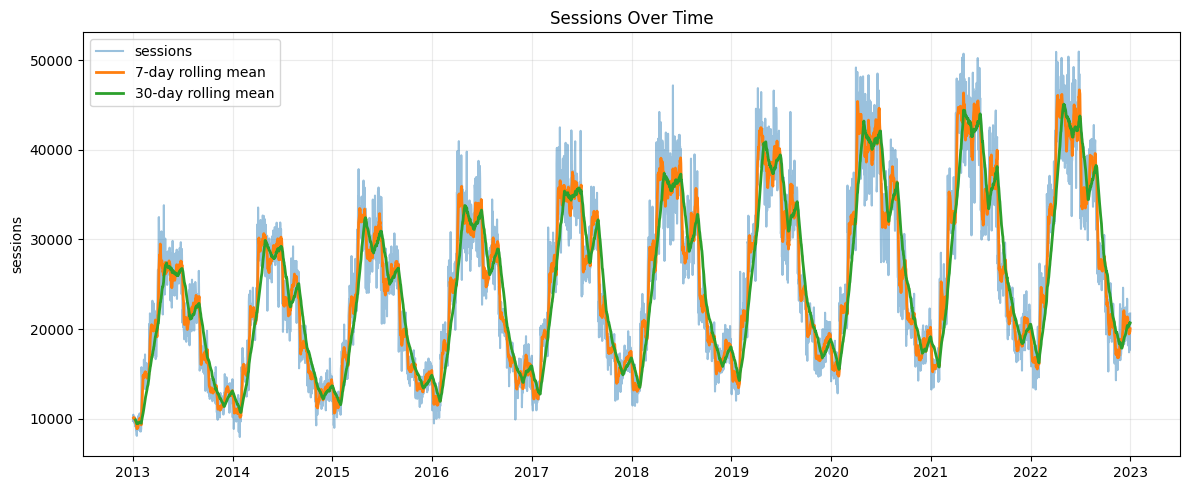

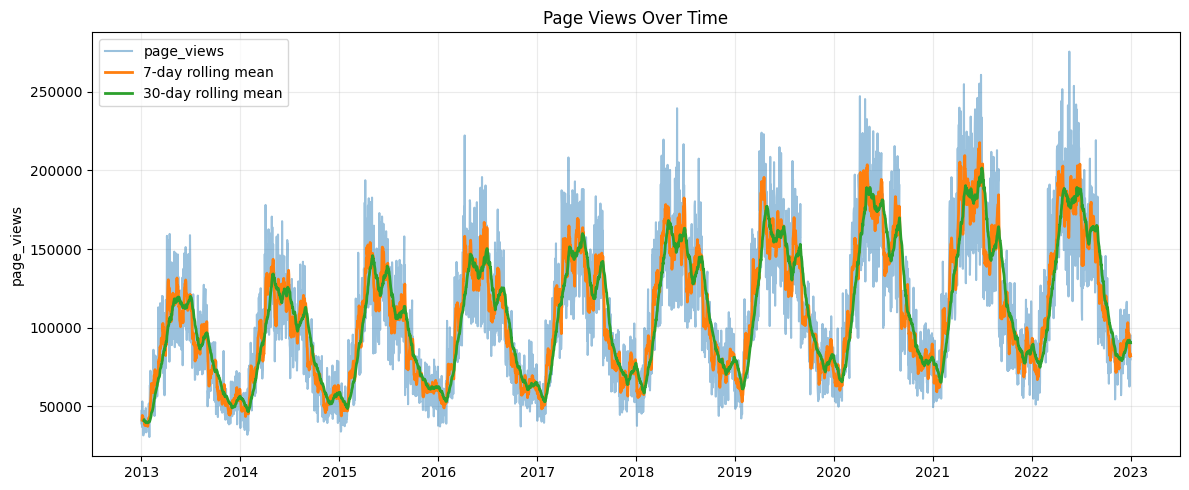

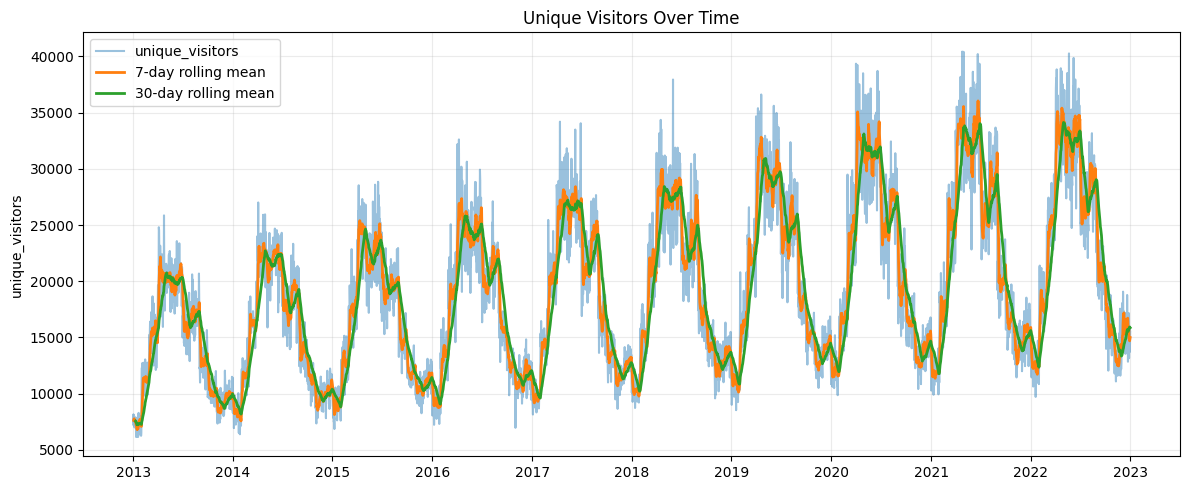

,metric,trend_direction,first_30_day_avg,last_30_day_avg,pct_change_first_to_last_30d,linear_daily_slope
0,sessions,increasing,"9,536.3667","20,692.9667",1.1699,3.5451
1,page_views,increasing,"40,060.5333","90,341.7333",1.2551,15.3503
2,unique_visitors,increasing,"7,279.9000","15,857.8333",1.1783,2.6980


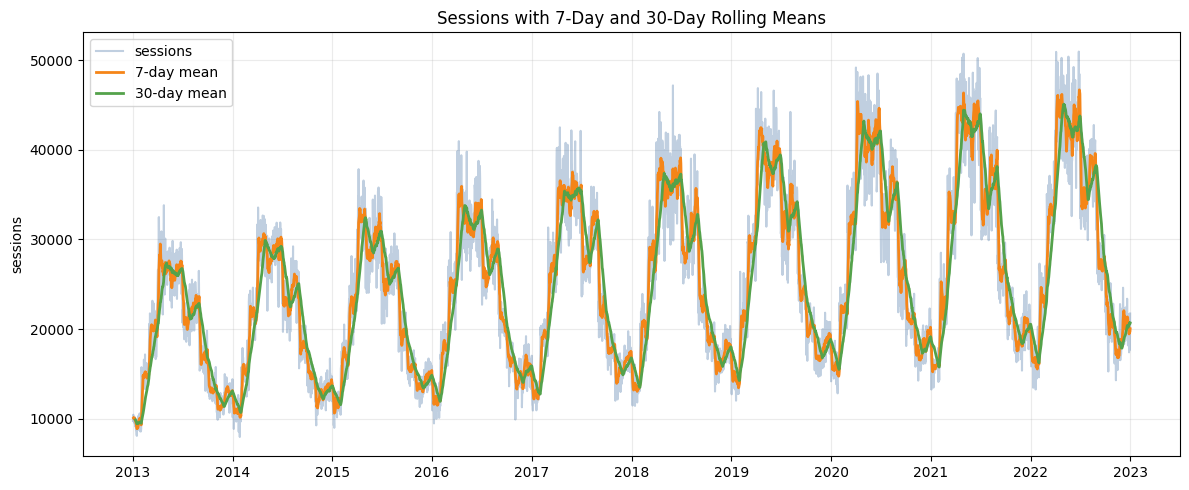

In [7]:
trend_summary = pd.DataFrame()

def trend_direction(series):
    s = series.dropna()
    if len(s) < 60:
        return 'insufficient data', np.nan, np.nan
    first = s.iloc[:30].mean()
    last = s.iloc[-30:].mean()
    pct_change = (last - first) / first if first not in [0, np.nan] and first != 0 else np.nan
    x = np.arange(len(s))
    slope = np.polyfit(x, s.values, 1)[0]
    if pd.isna(pct_change) or abs(pct_change) < 0.05:
        direction = 'stable'
    elif pct_change > 0:
        direction = 'increasing'
    else:
        direction = 'decreasing'
    return direction, pct_change, slope

if traffic_daily.empty or 'sessions' not in traffic_daily.columns:
    print('Traffic daily data or sessions are unavailable; trend analysis cannot be computed.')
else:
    rows = []
    for metric in traffic_metrics:
        if metric not in traffic_daily.columns:
            continue
        direction, pct_change, slope = trend_direction(traffic_daily[metric])
        rows.append({'metric': metric, 'trend_direction': direction, 'first_30_day_avg': traffic_daily[metric].iloc[:30].mean(), 'last_30_day_avg': traffic_daily[metric].iloc[-30:].mean(), 'pct_change_first_to_last_30d': pct_change, 'linear_daily_slope': slope})
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(traffic_daily['date'], traffic_daily[metric], alpha=0.45, label=metric)
        ax.plot(traffic_daily['date'], traffic_daily[metric].rolling(7, min_periods=3).mean(), label='7-day rolling mean', linewidth=2)
        ax.plot(traffic_daily['date'], traffic_daily[metric].rolling(30, min_periods=10).mean(), label='30-day rolling mean', linewidth=2)
        ax.set_title(f'{metric.replace("_", " ").title()} Over Time')
        ax.set_ylabel(metric)
        ax.legend()
        plt.tight_layout()
        plt.show()
    trend_summary = pd.DataFrame(rows)
    display(trend_summary)

    if 'sessions' in traffic_daily.columns:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(traffic_daily['date'], traffic_daily['sessions'], color='#4C78A8', alpha=0.35, label='sessions')
        ax.plot(traffic_daily['date'], traffic_daily['sessions'].rolling(7, min_periods=3).mean(), color='#F58518', label='7-day mean', linewidth=2)
        ax.plot(traffic_daily['date'], traffic_daily['sessions'].rolling(30, min_periods=10).mean(), color='#54A24B', label='30-day mean', linewidth=2)
        ax.set_title('Sessions with 7-Day and 30-Day Rolling Means')
        ax.set_ylabel('sessions')
        ax.legend()
        plt.tight_layout()
        plt.show()

## 8. Traffic Seasonality

Analyze average traffic by month of year, day of week, and quarter. Visible differences are exploratory seasonality signals.


,month,month_name,sessions,page_views,unique_visitors
0,1,Jan,"13,183.2290","56,567.7806","10,015.2742"
1,2,Feb,"19,530.2305","84,270.5851","14,817.4752"
2,3,Mar,"27,316.7613","119,645.4871","20,806.8419"
3,4,Apr,"36,913.4133","160,140.9100","28,024.0667"
4,5,May,"34,596.9194","147,776.2194","26,426.2484"
5,6,Jun,"36,197.9633","157,829.4733","27,513.5500"
6,7,Jul,"28,192.1581","122,409.5581","21,347.0355"
7,8,Aug,"31,493.8129","138,402.1548","23,916.4645"
8,9,Sep,"22,440.2567","96,909.6867","16,996.1400"
9,10,Oct,"18,111.5355","78,171.6839","13,810.8484"


,day_of_week,day_name,sessions,page_views,unique_visitors
0,0,Mon,"25,222.1823","108,396.7965","19,204.7601"
1,1,Tue,"24,914.7739","108,496.6897","18,925.2433"
2,2,Wed,"25,150.2031","109,863.3582","19,164.5670"
3,3,Thu,"25,153.9464","110,174.7241","19,120.0441"
4,4,Fri,"24,878.8640","107,441.7701","18,886.4540"
5,5,Sat,"24,922.6628","108,971.2644","18,914.4847"
6,6,Sun,"25,050.1056","106,958.3762","19,004.5585"


,quarter,sessions,page_views,unique_visitors
0,1,"20,024.9690","86,907.3370","15,225.4812"
1,2,"35,888.4154","155,166.7505","27,311.4527"
2,3,"27,429.0522","119,483.1924","20,794.0511"
3,4,"16,844.3793","72,984.8935","12,810.1696"


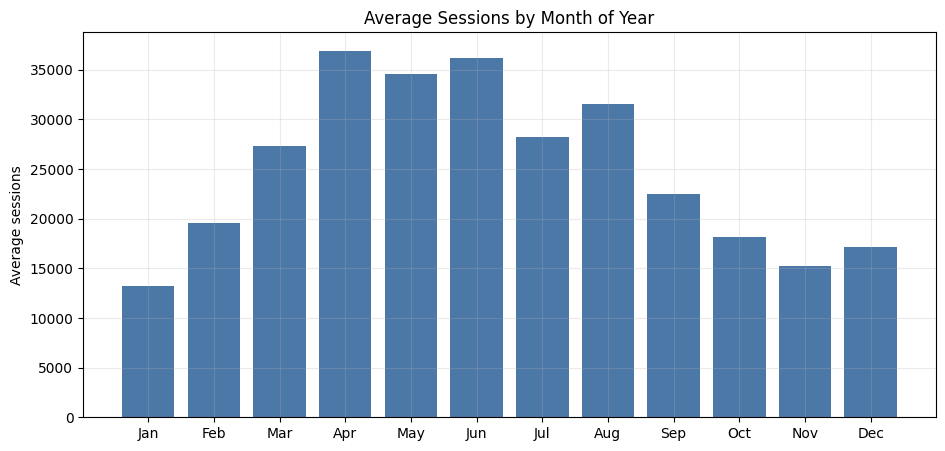

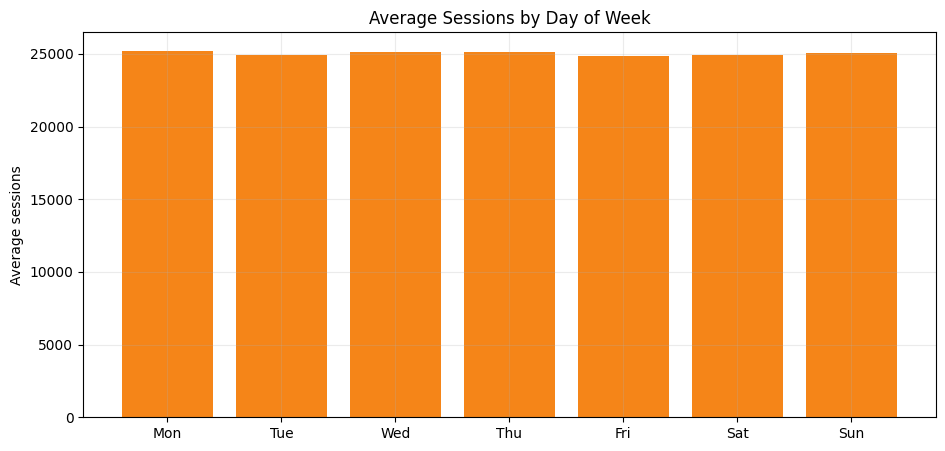

Monthly max/min average sessions ratio: 2.800
Day-of-week max/min average sessions ratio: 1.014


In [8]:
seasonality_tables = {}
if traffic_daily.empty or 'sessions' not in traffic_daily.columns:
    print('Traffic data is unavailable; seasonality analysis cannot be computed.')
else:
    ts = traffic_daily.copy()
    ts['month'] = ts['date'].dt.month
    ts['month_name'] = ts['date'].dt.month_name().str[:3]
    ts['day_of_week'] = ts['date'].dt.dayofweek
    ts['day_name'] = ts['date'].dt.day_name().str[:3]
    ts['quarter'] = ts['date'].dt.quarter
    agg_metrics = [m for m in traffic_metrics if m in ts.columns]
    month_table = ts.groupby(['month', 'month_name'])[agg_metrics].mean().reset_index().sort_values('month')
    dow_table = ts.groupby(['day_of_week', 'day_name'])[agg_metrics].mean().reset_index().sort_values('day_of_week')
    quarter_table = ts.groupby('quarter')[agg_metrics].mean().reset_index()
    seasonality_tables = {'month': month_table, 'day_of_week': dow_table, 'quarter': quarter_table}
    display(month_table)
    display(dow_table)
    display(quarter_table)

    fig, ax = plt.subplots()
    ax.bar(month_table['month_name'], month_table['sessions'], color='#4C78A8')
    ax.set_title('Average Sessions by Month of Year')
    ax.set_ylabel('Average sessions')
    plt.show()

    fig, ax = plt.subplots()
    ax.bar(dow_table['day_name'], dow_table['sessions'], color='#F58518')
    ax.set_title('Average Sessions by Day of Week')
    ax.set_ylabel('Average sessions')
    plt.show()

    seasonal_strength_month = month_table['sessions'].max() / month_table['sessions'].min() if month_table['sessions'].min() != 0 else np.nan
    seasonal_strength_dow = dow_table['sessions'].max() / dow_table['sessions'].min() if dow_table['sessions'].min() != 0 else np.nan
    print(f'Monthly max/min average sessions ratio: {seasonal_strength_month:,.3f}')
    print(f'Day-of-week max/min average sessions ratio: {seasonal_strength_dow:,.3f}')

## 9. Traffic Spike Detection

Detect unusually high traffic days with z-score, IQR, and percentile thresholds. Spikes are exploratory signals, not proof of an external event.


,date,sessions,page_views,unique_visitors,spike_metric,spike_value,z_score,percentile_rank,p95_threshold,p99_threshold
183,2022-05-19,50386,275560,38175,page_views,275560,3.7544,1.0000,"190,782.9000","223,688.3700"
184,2021-06-27,49137,260766,39354,page_views,260766,3.4217,0.9997,"190,782.9000","223,688.3700"
185,2021-06-21,50225,255212,40208,page_views,255212,3.2968,0.9995,"190,782.9000","223,688.3700"
186,2021-04-25,50274,254833,40430,page_views,254833,3.2883,0.9992,"190,782.9000","223,688.3700"
187,2022-06-05,47723,253750,37307,page_views,253750,3.2640,0.9989,"190,782.9000","223,688.3700"
188,2022-04-23,47534,251668,35380,page_views,251668,3.2171,0.9986,"190,782.9000","223,688.3700"
189,2020-04-06,48680,247194,39248,page_views,247194,3.1165,0.9984,"190,782.9000","223,688.3700"
190,2021-06-14,46537,246126,36237,page_views,246126,3.0925,0.9981,"190,782.9000","223,688.3700"
191,2020-04-25,45937,245372,32490,page_views,245372,3.0755,0.9978,"190,782.9000","223,688.3700"
192,2022-04-19,46622,244067,34253,page_views,244067,3.0462,0.9975,"190,782.9000","223,688.3700"


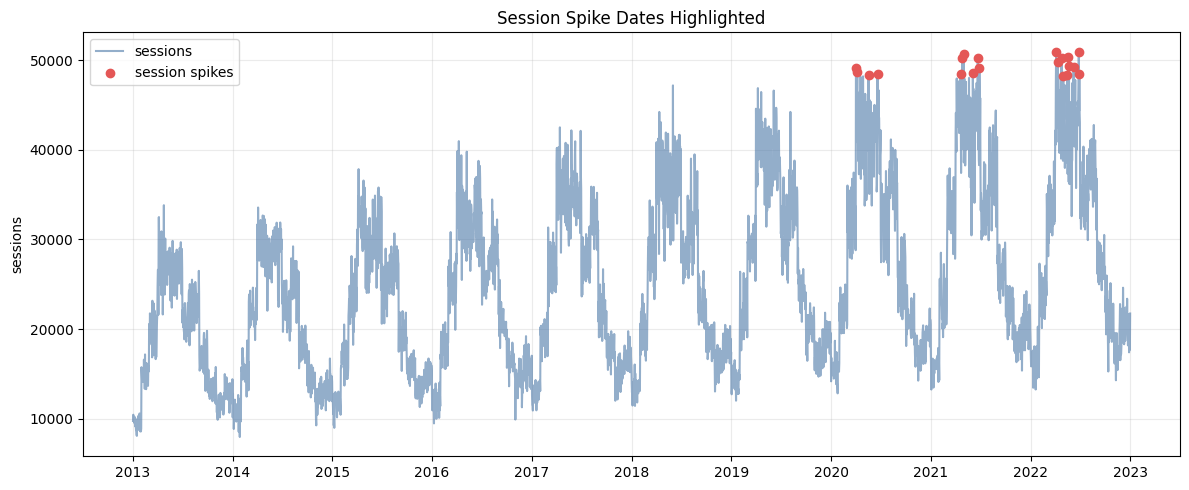

In [9]:
traffic_spikes = pd.DataFrame()

def spike_table(df, metric):
    s = df[metric].astype(float)
    mean = s.mean()
    std = s.std(ddof=0)
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    p95 = s.quantile(0.95)
    p99 = s.quantile(0.99)
    z = (s - mean) / std if std != 0 else pd.Series(0, index=s.index)
    flag = (z >= 3) | (s >= q3 + 1.5 * iqr) | (s >= p95)
    out = df.loc[flag, ['date'] + [m for m in traffic_metrics if m in df.columns]].copy()
    out['spike_metric'] = metric
    out['spike_value'] = df.loc[flag, metric].values
    out['z_score'] = z.loc[flag].values
    out['percentile_rank'] = s.rank(pct=True).loc[flag].values
    out['p95_threshold'] = p95
    out['p99_threshold'] = p99
    return out.sort_values(['percentile_rank', 'spike_value'], ascending=False)

if traffic_daily.empty:
    print('Traffic data is unavailable; spike detection cannot be computed.')
else:
    spike_parts = []
    for metric in traffic_metrics:
        if metric in traffic_daily.columns:
            spike_parts.append(spike_table(traffic_daily, metric))
    traffic_spikes = pd.concat(spike_parts, ignore_index=True) if spike_parts else pd.DataFrame()
    if traffic_spikes.empty:
        print('No traffic spikes detected by configured rules.')
    else:
        display(traffic_spikes.sort_values(['spike_metric', 'percentile_rank'], ascending=[True, False]).head(50))
        top_sessions_spikes = traffic_spikes[traffic_spikes['spike_metric'].eq('sessions')].head(20)
        if not top_sessions_spikes.empty and 'sessions' in traffic_daily.columns:
            fig, ax = plt.subplots(figsize=(12, 5))
            ax.plot(traffic_daily['date'], traffic_daily['sessions'], color='#4C78A8', alpha=0.6, label='sessions')
            ax.scatter(top_sessions_spikes['date'], top_sessions_spikes['sessions'], color='#E45756', label='session spikes', zorder=3)
            ax.set_title('Session Spike Dates Highlighted')
            ax.set_ylabel('sessions')
            ax.legend()
            plt.tight_layout()
            plt.show()

## 10. Join Traffic with Revenue and AOV

Join daily traffic, daily Revenue, and daily AOV by date, then report overlap and preview the aligned dataset.


In [10]:
joined = pd.DataFrame()
overlap_report = pd.DataFrame()
if traffic_daily.empty or sales_daily.empty:
    print('Traffic or sales daily data is unavailable; join analysis cannot be computed.')
else:
    joined = traffic_daily.merge(sales_daily, on='date', how='outer', indicator=True).sort_values('date')
    traffic_only = int((joined['_merge'] == 'left_only').sum())
    sales_only = int((joined['_merge'] == 'right_only').sum())
    overlap = joined[joined['_merge'] == 'both'].copy()
    overlap_rows = [
        {'metric': 'traffic_only_dates', 'value': traffic_only},
        {'metric': 'sales_only_dates', 'value': sales_only},
        {'metric': 'overlapping_traffic_revenue_dates', 'value': len(overlap)},
        {'metric': 'overlap_start_date', 'value': overlap['date'].min() if not overlap.empty else pd.NaT},
        {'metric': 'overlap_end_date', 'value': overlap['date'].max() if not overlap.empty else pd.NaT},
    ]
    joined = joined.drop(columns=['_merge'])
    if not aov_daily.empty:
        joined = joined.merge(aov_daily[['date', 'number_of_orders', 'aov']], on='date', how='left')
        aov_overlap = joined.dropna(subset=['aov'])
        if traffic_metrics:
            traffic_available = aov_overlap[traffic_metrics].notna().any(axis=1) if all(m in aov_overlap.columns for m in traffic_metrics) else pd.Series(False, index=aov_overlap.index)
            overlapping_traffic_aov_dates = int(traffic_available.sum())
        else:
            overlapping_traffic_aov_dates = 0
        overlap_rows.extend([
            {'metric': 'overlapping_traffic_aov_dates', 'value': overlapping_traffic_aov_dates},
            {'metric': 'aov_overlap_start_date', 'value': aov_overlap['date'].min() if not aov_overlap.empty else pd.NaT},
            {'metric': 'aov_overlap_end_date', 'value': aov_overlap['date'].max() if not aov_overlap.empty else pd.NaT},
        ])
    overlap_report = pd.DataFrame(overlap_rows)
    display(overlap_report)
    display(joined.head())
    display(joined.tail())


,metric,value
0,traffic_only_dates,0
1,sales_only_dates,181
2,overlapping_traffic_revenue_dates,3652
3,overlap_start_date,2013-01-01 00:00:00
4,overlap_end_date,2022-12-31 00:00:00
5,overlapping_traffic_aov_dates,3652
6,aov_overlap_start_date,2012-07-04 00:00:00
7,aov_overlap_end_date,2022-12-31 00:00:00


,date,sessions,page_views,unique_visitors,revenue,number_of_orders,aov
0,2012-07-04,NaN,NaN,NaN,"5,123,547.9400",153,"33,487.2414"
1,2012-07-05,NaN,NaN,NaN,"2,751,773.4500",88,"31,270.1528"
2,2012-07-06,NaN,NaN,NaN,"3,054,029.4200",82,"37,244.2612"
3,2012-07-07,NaN,NaN,NaN,"2,667,930.9400",65,"41,045.0914"
4,2012-07-08,NaN,NaN,NaN,"2,360,851.9000",83,"28,443.9988"


,date,sessions,page_views,unique_visitors,revenue,number_of_orders,aov
3828,2022-12-27,"17,416.0000","62,527.0000","13,150.0000","2,100,553.6600",97,"21,655.1924"
3829,2022-12-28,"21,071.0000","67,456.0000","15,979.0000","3,448,729.2000",144,"23,949.5083"
3830,2022-12-29,"20,884.0000","82,155.0000","14,640.0000","3,083,944.3300",126,"24,475.7487"
3831,2022-12-30,"17,679.0000","79,308.0000","13,713.0000","2,884,668.7600",97,"29,738.8532"
3832,2022-12-31,"21,743.0000","94,844.0000","15,512.0000","2,383,037.4800",72,"33,097.7428"


## 11. Revenue vs Traffic Relationship

Compare Revenue with same-day and lagged traffic. Same-day traffic can be useful for explanation, but is only valid as a forecast feature if it is known before prediction.


,traffic_feature,correlation_with_revenue,valid_days
5,sessions_roll_mean_7,0.3235,3649
3,sessions_lag_1,0.3216,3651
0,sessions,0.3211,3652
2,unique_visitors,0.3188,3652
4,sessions_lag_7,0.3092,3645
1,page_views,0.3016,3652


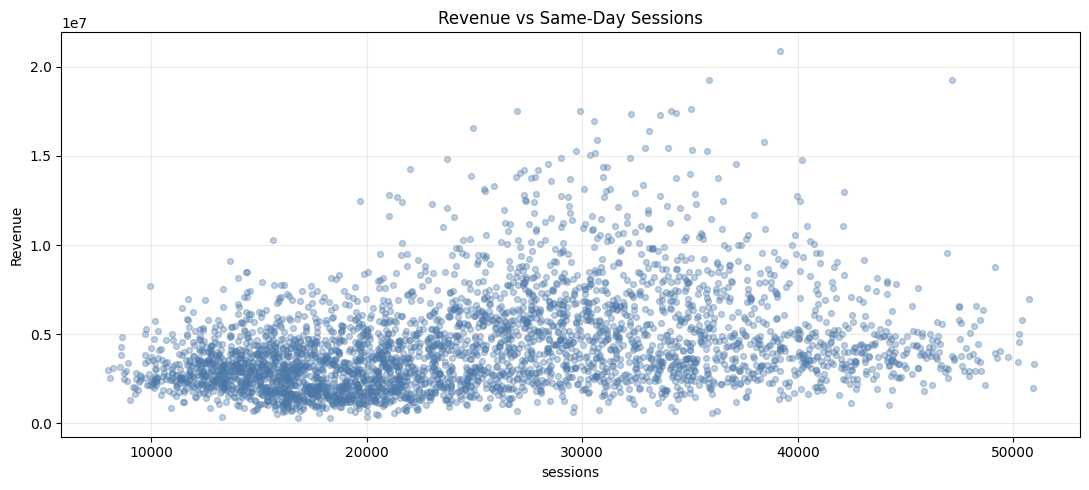

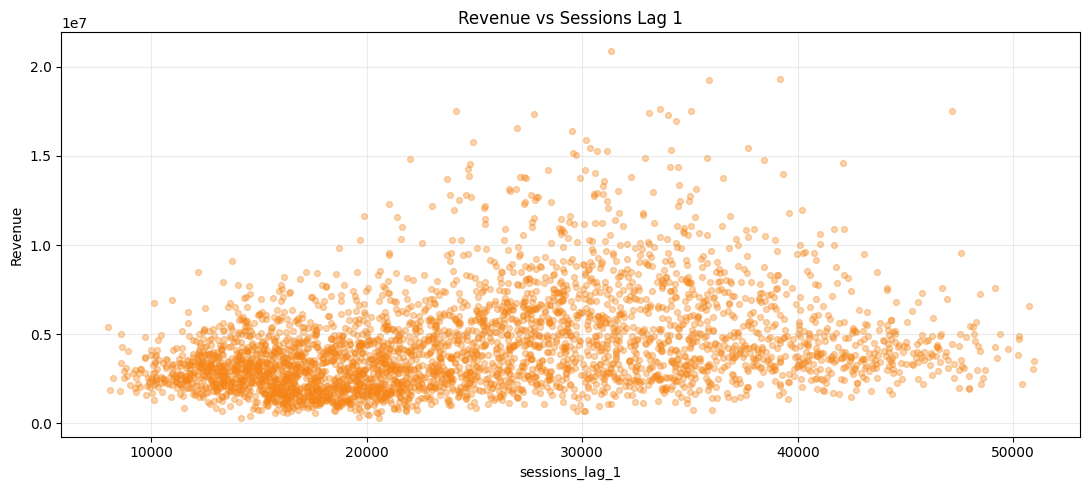

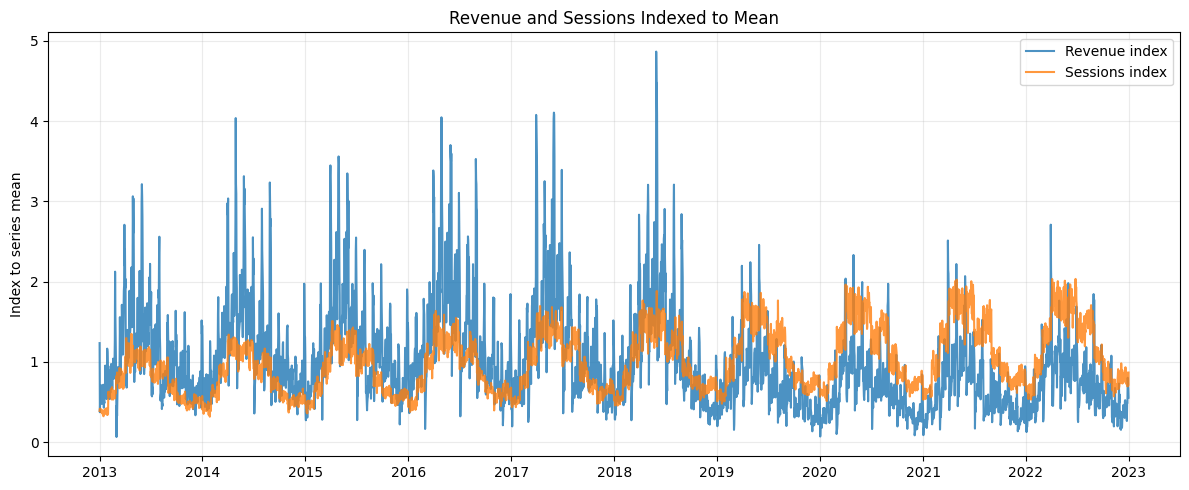

In [11]:
correlation_table = pd.DataFrame()
if joined.empty or 'revenue' not in joined.columns or 'sessions' not in joined.columns:
    print('Joined Revenue and sessions data is unavailable; relationship analysis cannot be computed.')
else:
    rel = joined.sort_values('date').copy()
    for metric in traffic_metrics:
        if metric in rel.columns:
            rel[f'{metric}_lag_1'] = rel[metric].shift(1)
            rel[f'{metric}_lag_7'] = rel[metric].shift(7)
            rel[f'{metric}_roll_mean_7'] = rel[metric].shift(1).rolling(7, min_periods=3).mean()
    corr_rows = []
    for col in [m for m in traffic_metrics if m in rel.columns] + ['sessions_lag_1', 'sessions_lag_7', 'sessions_roll_mean_7']:
        if col in rel.columns:
            valid = rel[['revenue', col]].replace([np.inf, -np.inf], np.nan).dropna()
            corr_rows.append({'traffic_feature': col, 'correlation_with_revenue': valid['revenue'].corr(valid[col]) if len(valid) >= 2 else np.nan, 'valid_days': len(valid)})
    correlation_table = pd.DataFrame(corr_rows).sort_values('correlation_with_revenue', ascending=False)
    display(correlation_table)

    sample = rel[['revenue', 'sessions']].replace([np.inf, -np.inf], np.nan).dropna()
    fig, ax = plt.subplots()
    ax.scatter(sample['sessions'], sample['revenue'], alpha=0.35, s=18, color='#4C78A8')
    ax.set_title('Revenue vs Same-Day Sessions')
    ax.set_xlabel('sessions')
    ax.set_ylabel('Revenue')
    plt.tight_layout()
    plt.show()

    if 'sessions_lag_1' in rel.columns:
        sample_lag = rel[['revenue', 'sessions_lag_1']].replace([np.inf, -np.inf], np.nan).dropna()
        fig, ax = plt.subplots()
        ax.scatter(sample_lag['sessions_lag_1'], sample_lag['revenue'], alpha=0.35, s=18, color='#F58518')
        ax.set_title('Revenue vs Sessions Lag 1')
        ax.set_xlabel('sessions_lag_1')
        ax.set_ylabel('Revenue')
        plt.tight_layout()
        plt.show()

    scaled = rel[['date', 'revenue', 'sessions']].dropna().copy()
    if not scaled.empty:
        scaled['revenue_index'] = scaled['revenue'] / scaled['revenue'].mean()
        scaled['sessions_index'] = scaled['sessions'] / scaled['sessions'].mean()
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(scaled['date'], scaled['revenue_index'], label='Revenue index', alpha=0.8)
        ax.plot(scaled['date'], scaled['sessions_index'], label='Sessions index', alpha=0.8)
        ax.set_title('Revenue and Sessions Indexed to Mean')
        ax.set_ylabel('Index to series mean')
        ax.legend()
        plt.tight_layout()
        plt.show()

## 12. Web Traffic vs AOV Relationship

Measure whether traffic volume moves with Average Order Value. This helps separate high-traffic days that increase total demand from high-traffic days that also change basket value.


,traffic_feature,correlation_with_aov,abs_correlation_with_aov,valid_days
5,sessions_roll_mean_7,0.2789,0.2789,3649
4,sessions_lag_7,0.2736,0.2736,3645
0,sessions,0.2716,0.2716,3652
3,sessions_lag_1,0.2714,0.2714,3651
2,unique_visitors,0.2702,0.2702,3652
1,page_views,0.2477,0.2477,3652


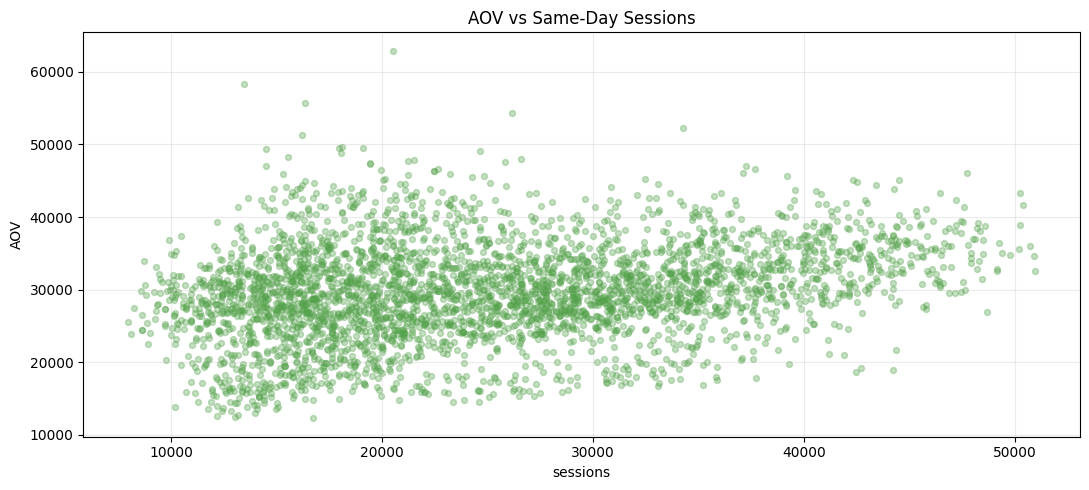

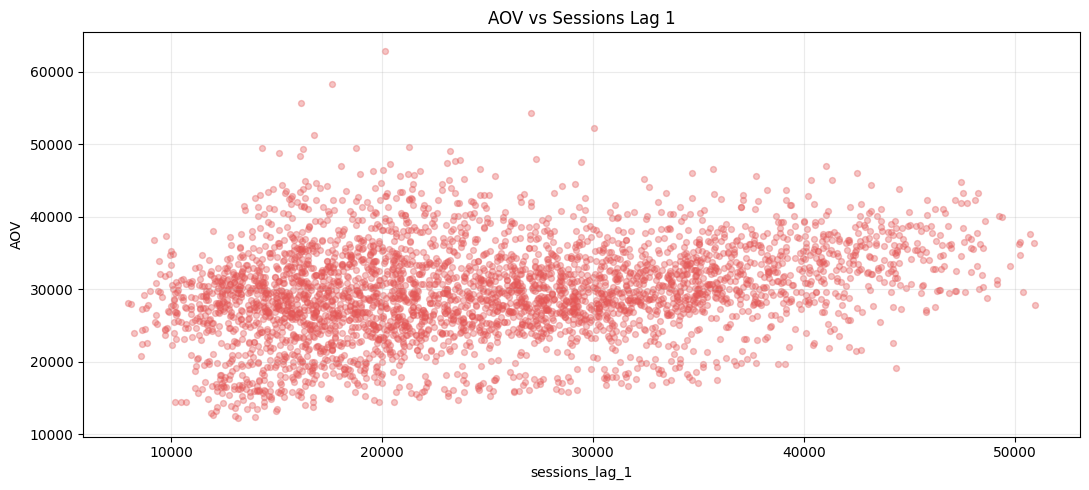

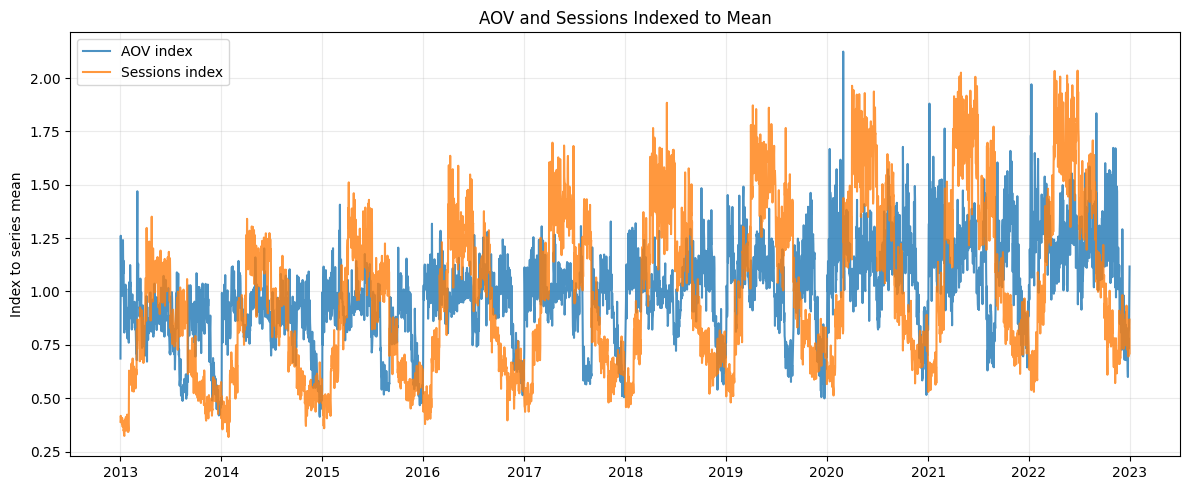

In [12]:
aov_correlation_table = pd.DataFrame()
if joined.empty or 'aov' not in joined.columns or joined['aov'].dropna().empty:
    print('Joined traffic and AOV data is unavailable; Web Traffic vs AOV analysis cannot be computed.')
else:
    aov_rel = joined.sort_values('date').copy()
    for metric in traffic_metrics:
        if metric in aov_rel.columns:
            aov_rel[f'{metric}_lag_1'] = aov_rel[metric].shift(1)
            aov_rel[f'{metric}_lag_7'] = aov_rel[metric].shift(7)
            aov_rel[f'{metric}_roll_mean_7'] = aov_rel[metric].shift(1).rolling(7, min_periods=3).mean()

    aov_corr_rows = []
    base_features = [m for m in traffic_metrics if m in aov_rel.columns]
    lag_features = ['sessions_lag_1', 'sessions_lag_7', 'sessions_roll_mean_7']
    for col in base_features + lag_features:
        if col in aov_rel.columns:
            valid = aov_rel[['aov', col]].replace([np.inf, -np.inf], np.nan).dropna()
            corr = valid['aov'].corr(valid[col]) if len(valid) >= 2 else np.nan
            aov_corr_rows.append({
                'traffic_feature': col,
                'correlation_with_aov': corr,
                'abs_correlation_with_aov': abs(corr) if pd.notna(corr) else np.nan,
                'valid_days': len(valid),
            })
    aov_correlation_table = pd.DataFrame(aov_corr_rows).sort_values('abs_correlation_with_aov', ascending=False)
    display(aov_correlation_table)

    if 'sessions' in aov_rel.columns:
        sample = aov_rel[['aov', 'sessions']].replace([np.inf, -np.inf], np.nan).dropna()
        fig, ax = plt.subplots()
        ax.scatter(sample['sessions'], sample['aov'], alpha=0.35, s=18, color='#54A24B')
        ax.set_title('AOV vs Same-Day Sessions')
        ax.set_xlabel('sessions')
        ax.set_ylabel('AOV')
        plt.tight_layout()
        plt.show()

        if 'sessions_lag_1' in aov_rel.columns:
            sample_lag = aov_rel[['aov', 'sessions_lag_1']].replace([np.inf, -np.inf], np.nan).dropna()
            fig, ax = plt.subplots()
            ax.scatter(sample_lag['sessions_lag_1'], sample_lag['aov'], alpha=0.35, s=18, color='#E45756')
            ax.set_title('AOV vs Sessions Lag 1')
            ax.set_xlabel('sessions_lag_1')
            ax.set_ylabel('AOV')
            plt.tight_layout()
            plt.show()

        scaled = aov_rel[['date', 'aov', 'sessions']].dropna().copy()
        aov_mean = scaled['aov'].mean() if not scaled.empty else np.nan
        sessions_mean = scaled['sessions'].mean() if not scaled.empty else np.nan
        if not scaled.empty and aov_mean != 0 and sessions_mean != 0:
            scaled['aov_index'] = scaled['aov'] / aov_mean
            scaled['sessions_index'] = scaled['sessions'] / sessions_mean
            fig, ax = plt.subplots(figsize=(12, 5))
            ax.plot(scaled['date'], scaled['aov_index'], label='AOV index', alpha=0.8)
            ax.plot(scaled['date'], scaled['sessions_index'], label='Sessions index', alpha=0.8)
            ax.set_title('AOV and Sessions Indexed to Mean')
            ax.set_ylabel('Index to series mean')
            ax.legend()
            plt.tight_layout()
            plt.show()


## 13. Traffic Spike and Revenue Spike Overlap

Detect Revenue spikes with comparable simple rules, then compare same-day and 1-7 day follow-up overlap with traffic spikes.


In [13]:
spike_overlap_table = pd.DataFrame()
revenue_spikes = pd.DataFrame()

if joined.empty or 'revenue' not in joined.columns or 'sessions' not in joined.columns:
    print('Joined data is unavailable; traffic-Revenue spike overlap cannot be computed.')
else:
    overlap_base = joined.dropna(subset=['date']).sort_values('date').copy()
    revenue_spikes = spike_table(overlap_base.rename(columns={'revenue': '_revenue_metric'}), '_revenue_metric')
    if not revenue_spikes.empty:
        revenue_spikes['revenue'] = revenue_spikes['spike_value']
    revenue_spike_dates = set(revenue_spikes['date'])
    session_spike_dates = set(traffic_spikes.loc[traffic_spikes['spike_metric'].eq('sessions'), 'date']) if not traffic_spikes.empty else set()
    same_day = sorted(session_spike_dates & revenue_spike_dates)
    followed_rows = []
    for d in sorted(session_spike_dates):
        future_rev = [r for r in revenue_spike_dates if pd.Timedelta(days=1) <= (r - d) <= pd.Timedelta(days=7)]
        for r in sorted(future_rev):
            followed_rows.append({'traffic_spike_date': d, 'revenue_spike_date': r, 'days_after_traffic_spike': (r - d).days})
    revenue_without_traffic = sorted(revenue_spike_dates - session_spike_dates)
    traffic_without_revenue = sorted(session_spike_dates - revenue_spike_dates)
    spike_overlap_table = pd.DataFrame([
        {'category': 'same_day_traffic_and_revenue_spikes', 'count': len(same_day), 'example_dates': ', '.join(str(pd.Timestamp(d).date()) for d in same_day[:10])},
        {'category': 'traffic_spikes_followed_by_revenue_spike_1_to_7d', 'count': len(followed_rows), 'example_dates': ', '.join(f"{pd.Timestamp(r['traffic_spike_date']).date()}->{pd.Timestamp(r['revenue_spike_date']).date()}" for r in followed_rows[:10])},
        {'category': 'revenue_spikes_without_same_day_session_spike', 'count': len(revenue_without_traffic), 'example_dates': ', '.join(str(pd.Timestamp(d).date()) for d in revenue_without_traffic[:10])},
        {'category': 'session_spikes_without_same_day_revenue_spike', 'count': len(traffic_without_revenue), 'example_dates': ', '.join(str(pd.Timestamp(d).date()) for d in traffic_without_revenue[:10])},
    ])
    display(spike_overlap_table)
    if followed_rows:
        display(pd.DataFrame(followed_rows).head(50))
    if not revenue_spikes.empty:
        print('Top Revenue spike dates:')
        display(revenue_spikes[['date', 'revenue', 'z_score', 'percentile_rank']].head(20))

,category,count,example_dates
0,same_day_traffic_and_revenue_spikes,2,"2018-06-01, 2021-04-29"
1,traffic_spikes_followed_by_revenue_spike_1_to_7d,14,"2018-04-12->2018-04-18, 2018-04-17->2018-04-18..."
2,revenue_spikes_without_same_day_session_spike,190,"2012-08-02, 2012-08-28, 2012-08-30, 2013-03-30..."
3,session_spikes_without_same_day_revenue_spike,181,"2017-04-13, 2018-04-12, 2018-04-17, 2019-04-01..."


,traffic_spike_date,revenue_spike_date,days_after_traffic_spike
0,2018-04-12,2018-04-18,6
1,2018-04-17,2018-04-18,1
2,2018-04-17,2018-04-24,7
3,2018-06-01,2018-06-02,1
4,2018-06-01,2018-06-03,2
5,2019-04-24,2019-04-29,5
6,2020-04-23,2020-04-29,6
7,2020-04-25,2020-04-29,4
8,2020-04-27,2020-04-29,2
9,2021-04-22,2021-04-29,7


Top Revenue spike dates:


,date,revenue,z_score,percentile_rank
2156,2018-05-30,"20,905,271.3500",6.3321,1.0000
2157,2018-05-31,"19,289,944.1200",5.7167,0.9997
2158,2018-06-01,"19,245,165.7800",5.6996,0.9995
1793,2017-06-01,"17,639,270.8800",5.0877,0.9992
2159,2018-06-02,"17,529,108.3400",5.0457,0.9990
1794,2017-06-02,"17,528,852.8800",5.0456,0.9987
1730,2017-03-30,"17,516,038.8200",5.0408,0.9984
1394,2016-04-28,"17,388,183.1900",4.9920,0.9982
664,2014-04-29,"17,347,427.2700",4.9765,0.9979
1792,2017-05-31,"17,314,841.8600",4.9641,0.9977


## 14. Traffic Efficiency Metrics

When columns are available, calculate Revenue per session, Revenue per unique visitor, page views per session, and sessions per unique visitor. Flag high-traffic/low-efficiency and low-traffic/high-efficiency days.


In [14]:
efficiency = pd.DataFrame()
if joined.empty or 'revenue' not in joined.columns or 'sessions' not in joined.columns:
    print('Joined Revenue and sessions data is unavailable; efficiency metrics cannot be computed.')
else:
    efficiency = joined.sort_values('date').copy()
    efficiency['revenue_per_session'] = efficiency['revenue'] / efficiency['sessions'].replace(0, np.nan)
    if 'unique_visitors' in efficiency.columns:
        efficiency['revenue_per_unique_visitor'] = efficiency['revenue'] / efficiency['unique_visitors'].replace(0, np.nan)
        efficiency['sessions_per_unique_visitor'] = efficiency['sessions'] / efficiency['unique_visitors'].replace(0, np.nan)
    if 'page_views' in efficiency.columns:
        efficiency['page_views_per_session'] = efficiency['page_views'] / efficiency['sessions'].replace(0, np.nan)
    eff_cols = ['date', 'revenue', 'sessions', 'revenue_per_session']
    for c in ['unique_visitors', 'page_views', 'revenue_per_unique_visitor', 'page_views_per_session', 'sessions_per_unique_visitor']:
        if c in efficiency.columns:
            eff_cols.append(c)
    display(efficiency[eff_cols].describe().T)
    high_traffic_low_eff = efficiency[(efficiency['sessions'] >= efficiency['sessions'].quantile(0.90)) & (efficiency['revenue_per_session'] <= efficiency['revenue_per_session'].quantile(0.10))]
    low_traffic_high_eff = efficiency[(efficiency['sessions'] <= efficiency['sessions'].quantile(0.10)) & (efficiency['revenue_per_session'] >= efficiency['revenue_per_session'].quantile(0.90))]
    print('High traffic but low Revenue per session days:')
    display(high_traffic_low_eff[eff_cols].head(20))
    print('Low traffic but high Revenue per session days:')
    display(low_traffic_high_eff[eff_cols].head(20))

,count,mean,min,25%,50%,75%,max,std
date,3833,2017-10-02 00:00:00,2012-07-04 00:00:00,2015-02-17 00:00:00,2017-10-02 00:00:00,2020-05-17 00:00:00,2022-12-31 00:00:00,NaN
revenue,"3,833.0000","4,286,584.0296","279,813.9400","2,471,088.8200","3,647,303.9000","5,350,877.2000","20,905,271.3500","2,624,840.1982"
sessions,"3,652.0000","25,041.7681","7,973.0000","17,099.2500","23,633.5000","31,782.7500","50,947.0000","9,422.6093"
revenue_per_session,"3,652.0000",182.7231,15.3113,101.4641,164.1668,236.9584,778.0647,104.8779
unique_visitors,"3,652.0000","19,031.4044","6,136.0000","12,915.0000","17,924.0000","24,191.7500","40,430.0000","7,237.9531"
page_views,"3,652.0000","108,615.2245","30,451.0000","72,982.0000","101,010.5000","138,086.0000","275,560.0000","44,472.0555"
revenue_per_unique_visitor,"3,652.0000",240.8410,19.4721,133.0920,216.2338,313.0548,"1,110.0345",138.5700
page_views_per_session,"3,652.0000",4.3362,3.2001,3.7755,4.3406,4.8990,5.4999,0.6584
sessions_per_unique_visitor,"3,652.0000",1.3187,1.2197,1.2671,1.3170,1.3676,1.4286,0.0594


High traffic but low Revenue per session days:


,date,revenue,sessions,revenue_per_session,unique_visitors,page_views,revenue_per_unique_visitor,page_views_per_session,sessions_per_unique_visitor
2465,2019-04-04,"2,048,272.6300","40,892.0000",50.0898,"31,638.0000","200,895.0000",64.7409,4.9128,1.2925
2469,2019-04-08,"3,104,721.2800","46,874.0000",66.2355,"35,394.0000","212,734.0000",87.7189,4.5384,1.3243
2495,2019-05-04,"2,045,383.7600","40,801.0000",50.1307,"32,941.0000","153,355.0000",62.0923,3.7586,1.2386
2496,2019-05-05,"2,460,393.4500","43,470.0000",56.5998,"31,878.0000","145,614.0000",77.1815,3.3498,1.3636
2516,2019-05-25,"2,703,860.1700","42,312.0000",63.9029,"31,516.0000","205,258.0000",85.7933,4.8511,1.3426
2527,2019-06-05,"3,116,184.2200","46,601.0000",66.8695,"35,608.0000","188,669.0000",87.5136,4.0486,1.3087
2588,2019-08-05,"1,043,419.2000","44,223.0000",23.5945,"32,371.0000","155,964.0000",32.2331,3.5268,1.3661
2603,2019-08-20,"2,278,154.5100","38,795.0000",58.7229,"29,098.0000","167,871.0000",78.2925,4.3271,1.3333
2831,2020-04-04,"2,596,249.8400","44,615.0000",58.1923,"33,264.0000","158,048.0000",78.0498,3.5425,1.3412
2832,2020-04-05,"2,270,549.3500","45,794.0000",49.5818,"33,390.0000","205,475.0000",68.0009,4.4869,1.3715


Low traffic but high Revenue per session days:


,date,revenue,sessions,revenue_per_session,unique_visitors,page_views,revenue_per_unique_visitor,page_views_per_session,sessions_per_unique_visitor
181,2013-01-01,"5,304,546.9900","9,760.0000",543.4987,"7,253.0000","39,093.0000",731.3590,4.0054,1.3457
192,2013-01-12,"2,814,596.5300","8,730.0000",322.4051,"6,136.0000","33,336.0000",458.7022,3.8186,1.4228
193,2013-01-13,"2,919,719.6200","8,818.0000",331.1091,"6,863.0000","35,427.0000",425.4291,4.0176,1.2849
194,2013-01-14,"3,077,677.2800","8,230.0000",373.9584,"6,203.0000","35,402.0000",496.1595,4.3016,1.3268
201,2013-01-21,"4,100,379.4200","10,339.0000",396.5934,"8,283.0000","40,661.0000",495.0355,3.9328,1.2482
202,2013-01-22,"3,538,734.1200","10,100.0000",350.3697,"7,469.0000","39,597.0000",473.7895,3.9205,1.3523
207,2013-01-27,"3,818,881.2900","8,604.0000",443.8495,"6,327.0000","44,601.0000",603.5848,5.1838,1.3599
208,2013-01-28,"5,008,712.7700","9,701.0000",516.3089,"7,636.0000","51,697.0000",655.9341,5.3290,1.2704
209,2013-01-29,"4,833,870.4300","8,638.0000",559.6053,"6,928.0000","42,663.0000",697.7296,4.9390,1.2468
210,2013-01-30,"4,296,295.3700","8,596.0000",499.8017,"6,245.0000","30,451.0000",687.9576,3.5425,1.3765


## 15. Leakage-Safe Traffic Forecast Feature Preview

Create daily traffic feature candidates. Lagged and rolling features are shifted before rolling, so date `t` does not use traffic from date `t`. Raw same-day traffic features require future/same-day traffic to be known before prediction.


In [15]:
feature_preview = pd.DataFrame()
feature_registry = pd.DataFrame()
if joined.empty:
    print('Joined data is unavailable; forecast feature preview cannot be built.')
else:
    feature_preview = joined.sort_values('date').copy()
    if 'sessions' in feature_preview.columns:
        feature_preview['sessions_lag_1'] = feature_preview['sessions'].shift(1)
        feature_preview['sessions_lag_7'] = feature_preview['sessions'].shift(7)
        feature_preview['sessions_lag_30'] = feature_preview['sessions'].shift(30)
        feature_preview['sessions_roll_mean_7'] = feature_preview['sessions'].shift(1).rolling(7, min_periods=3).mean()
        feature_preview['sessions_roll_mean_30'] = feature_preview['sessions'].shift(1).rolling(30, min_periods=7).mean()
    if 'page_views' in feature_preview.columns:
        feature_preview['page_views_lag_1'] = feature_preview['page_views'].shift(1)
    if 'unique_visitors' in feature_preview.columns:
        feature_preview['unique_visitors_lag_1'] = feature_preview['unique_visitors'].shift(1)
    if 'sessions' in feature_preview.columns:
        spike_threshold = feature_preview['sessions'].quantile(0.95)
        feature_preview['traffic_spike'] = feature_preview['sessions'] >= spike_threshold
        feature_preview['traffic_spike_lag_1'] = feature_preview['traffic_spike'].shift(1).astype('boolean')
    if {'revenue', 'sessions'}.issubset(feature_preview.columns):
        feature_preview['revenue_per_session'] = feature_preview['revenue'] / feature_preview['sessions'].replace(0, np.nan)
        feature_preview['revenue_per_session_lag_1'] = feature_preview['revenue_per_session'].shift(1)

    preview_cols = ['date']
    for c in ['revenue', 'sessions', 'unique_visitors', 'page_views', 'sessions_lag_1', 'sessions_lag_7', 'sessions_lag_30', 'sessions_roll_mean_7', 'sessions_roll_mean_30', 'page_views_lag_1', 'unique_visitors_lag_1', 'traffic_spike_lag_1', 'revenue_per_session_lag_1']:
        if c in feature_preview.columns:
            preview_cols.append(c)
    display(feature_preview[preview_cols].head(40))

    known_future = [c for c in ['sessions', 'unique_visitors', 'page_views'] if c in feature_preview.columns]
    historical_safe = [c for c in ['sessions_lag_1', 'sessions_lag_7', 'sessions_lag_30', 'sessions_roll_mean_7', 'sessions_roll_mean_30', 'page_views_lag_1', 'unique_visitors_lag_1', 'traffic_spike_lag_1', 'revenue_per_session_lag_1'] if c in feature_preview.columns]
    feature_registry = pd.DataFrame({
        'feature': known_future + historical_safe,
        'feature_type': ['requires known future/same-day traffic'] * len(known_future) + ['historical lag/rolling only'] * len(historical_safe),
        'forecast_use_note': ['Use only if this value is genuinely known before prediction for the forecast/test date.'] * len(known_future) + ['Leakage-safe candidate because it uses shifted history.'] * len(historical_safe),
    })
    display(feature_registry)

,date,revenue,sessions,unique_visitors,page_views,sessions_lag_1,sessions_lag_7,sessions_lag_30,sessions_roll_mean_7,sessions_roll_mean_30,page_views_lag_1,unique_visitors_lag_1,traffic_spike_lag_1,revenue_per_session_lag_1
0,2012-07-04,"5,123,547.9400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
1,2012-07-05,"2,751,773.4500",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
2,2012-07-06,"3,054,029.4200",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
3,2012-07-07,"2,667,930.9400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
4,2012-07-08,"2,360,851.9000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
5,2012-07-09,"3,548,386.4600",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
6,2012-07-10,"5,234,938.6200",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
7,2012-07-11,"5,582,884.7800",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
8,2012-07-12,"5,734,632.0200",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
9,2012-07-13,"5,309,511.7100",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN


,feature,feature_type,forecast_use_note
0,sessions,requires known future/same-day traffic,Use only if this value is genuinely known befo...
1,unique_visitors,requires known future/same-day traffic,Use only if this value is genuinely known befo...
2,page_views,requires known future/same-day traffic,Use only if this value is genuinely known befo...
3,sessions_lag_1,historical lag/rolling only,Leakage-safe candidate because it uses shifted...
4,sessions_lag_7,historical lag/rolling only,Leakage-safe candidate because it uses shifted...
5,sessions_lag_30,historical lag/rolling only,Leakage-safe candidate because it uses shifted...
6,sessions_roll_mean_7,historical lag/rolling only,Leakage-safe candidate because it uses shifted...
7,sessions_roll_mean_30,historical lag/rolling only,Leakage-safe candidate because it uses shifted...
8,page_views_lag_1,historical lag/rolling only,Leakage-safe candidate because it uses shifted...
9,unique_visitors_lag_1,historical lag/rolling only,Leakage-safe candidate because it uses shifted...


## 16. Key Observations and Warnings

Final concise summary with trend, seasonality, spike, correlation, AOV, efficiency, and forecasting leakage notes.


In [16]:
def fmt(x, digits=4):
    return 'n/a' if pd.isna(x) else f'{x:,.{digits}f}'

summary_lines = []
if not trend_summary.empty:
    for metric in ['sessions', 'page_views', 'unique_visitors']:
        row = trend_summary[trend_summary['metric'].eq(metric)]
        if not row.empty:
            r = row.iloc[0]
            summary_lines.append(f"{metric}: {r['trend_direction']} over time; first 30-day avg {fmt(r['first_30_day_avg'], 2)}, last 30-day avg {fmt(r['last_30_day_avg'], 2)}, change {fmt(r['pct_change_first_to_last_30d'] * 100, 2)}%.")
else:
    summary_lines.append('Traffic trend could not be summarized because traffic data or metric columns were unavailable.')

if seasonality_tables:
    month_ratio = seasonality_tables['month']['sessions'].max() / seasonality_tables['month']['sessions'].min() if seasonality_tables['month']['sessions'].min() != 0 else np.nan
    dow_ratio = seasonality_tables['day_of_week']['sessions'].max() / seasonality_tables['day_of_week']['sessions'].min() if seasonality_tables['day_of_week']['sessions'].min() != 0 else np.nan
    summary_lines.append(f"Traffic seasonality is visible if max/min period ratios are meaningfully above 1. Monthly sessions max/min ratio: {fmt(month_ratio, 3)}; day-of-week ratio: {fmt(dow_ratio, 3)}.")

if not traffic_spikes.empty:
    top_spike_dates = traffic_spikes[traffic_spikes['spike_metric'].eq('sessions')].sort_values('spike_value', ascending=False).head(5)['date'].dt.strftime('%Y-%m-%d').tolist()
    summary_lines.append('Strongest session spike dates: ' + ', '.join(top_spike_dates))
else:
    summary_lines.append('No traffic spikes were detected by the configured rules, or traffic data was unavailable.')

if not spike_overlap_table.empty:
    for _, row in spike_overlap_table.iterrows():
        summary_lines.append(f"{row['category']}: {int(row['count'])}; examples: {row['example_dates'] or 'none'}.")

if not correlation_table.empty:
    def corr_for(feature):
        row = correlation_table[correlation_table['traffic_feature'].eq(feature)]
        return row.iloc[0]['correlation_with_revenue'] if not row.empty else np.nan
    summary_lines.append(f"Correlation with Revenue: same-day sessions {fmt(corr_for('sessions'), 4)}, page views {fmt(corr_for('page_views'), 4)}, unique visitors {fmt(corr_for('unique_visitors'), 4)}.")
    summary_lines.append(f"Lagged traffic correlation with Revenue: sessions_lag_1 {fmt(corr_for('sessions_lag_1'), 4)}, sessions_lag_7 {fmt(corr_for('sessions_lag_7'), 4)}, sessions_roll_mean_7 {fmt(corr_for('sessions_roll_mean_7'), 4)}.")
    best = correlation_table.dropna(subset=['correlation_with_revenue']).iloc[0]
    summary_lines.append(f"The strongest displayed traffic-Revenue alignment is {best['traffic_feature']} with correlation {fmt(best['correlation_with_revenue'], 4)}.")

if not aov_correlation_table.empty:
    def aov_corr_for(feature):
        row = aov_correlation_table[aov_correlation_table['traffic_feature'].eq(feature)]
        return row.iloc[0]['correlation_with_aov'] if not row.empty else np.nan
    summary_lines.append(f"Correlation with AOV: same-day sessions {fmt(aov_corr_for('sessions'), 4)}, page views {fmt(aov_corr_for('page_views'), 4)}, unique visitors {fmt(aov_corr_for('unique_visitors'), 4)}.")
    summary_lines.append(f"Lagged traffic correlation with AOV: sessions_lag_1 {fmt(aov_corr_for('sessions_lag_1'), 4)}, sessions_lag_7 {fmt(aov_corr_for('sessions_lag_7'), 4)}, sessions_roll_mean_7 {fmt(aov_corr_for('sessions_roll_mean_7'), 4)}.")
    best_aov = aov_correlation_table.dropna(subset=['correlation_with_aov']).sort_values('abs_correlation_with_aov', ascending=False).iloc[0]
    summary_lines.append(f"The strongest displayed traffic-AOV alignment is {best_aov['traffic_feature']} with correlation {fmt(best_aov['correlation_with_aov'], 4)}.")

if not efficiency.empty and 'revenue_per_session' in efficiency.columns:
    summary_lines.append(f"Revenue per session median is {fmt(efficiency['revenue_per_session'].median(), 2)}; high-traffic/low-efficiency days and low-traffic/high-efficiency days are listed above when present.")

if traffic_warnings:
    summary_lines.append('Traffic warnings: ' + '; '.join(traffic_warnings))
if sales_warnings:
    summary_lines.append('Sales warnings: ' + '; '.join(sales_warnings))
if aov_warnings:
    summary_lines.append('AOV warnings: ' + '; '.join(aov_warnings))

summary_lines.append('Recommended forecast features: sessions_lag_1, sessions_lag_7, sessions_lag_30, sessions_roll_mean_7, sessions_roll_mean_30, page_views_lag_1, unique_visitors_lag_1, traffic_spike_lag_1, and revenue_per_session_lag_1 where appropriate.')
summary_lines.append('Leakage warning: true future sessions, unique visitors, page views, and same-day AOV must not be used directly unless they are known before prediction. Otherwise forecast traffic first or use only historical lagged/pattern features.')
summary_lines.append('Causal caution: this is observational EDA. Traffic, Revenue, and AOV can move together because of marketing, seasonality, assortment, promotions, stock availability, and other confounders.')

print('KEY OBSERVATIONS AND WARNINGS')
for line in summary_lines:
    print('-', line)


KEY OBSERVATIONS AND WARNINGS
- sessions: increasing over time; first 30-day avg 9,536.37, last 30-day avg 20,692.97, change 116.99%.
- page_views: increasing over time; first 30-day avg 40,060.53, last 30-day avg 90,341.73, change 125.51%.
- unique_visitors: increasing over time; first 30-day avg 7,279.90, last 30-day avg 15,857.83, change 117.83%.
- Traffic seasonality is visible if max/min period ratios are meaningfully above 1. Monthly sessions max/min ratio: 2.800; day-of-week ratio: 1.014.
- Strongest session spike dates: 2022-06-26, 2022-04-04, 2021-04-30, 2022-05-19, 2021-04-25
- same_day_traffic_and_revenue_spikes: 2; examples: 2018-06-01, 2021-04-29.
- traffic_spikes_followed_by_revenue_spike_1_to_7d: 14; examples: 2018-04-12->2018-04-18, 2018-04-17->2018-04-18, 2018-04-17->2018-04-24, 2018-06-01->2018-06-02, 2018-06-01->2018-06-03, 2019-04-24->2019-04-29, 2020-04-23->2020-04-29, 2020-04-25->2020-04-29, 2020-04-27->2020-04-29, 2021-04-22->2021-04-29.
- revenue_spikes_without_

## Executive Storytelling Hook: Growth Illusion

Indexed view of Sessions, Revenue, and Order Count to show the post-2017 divergence between acquisition growth and monetization efficiency.

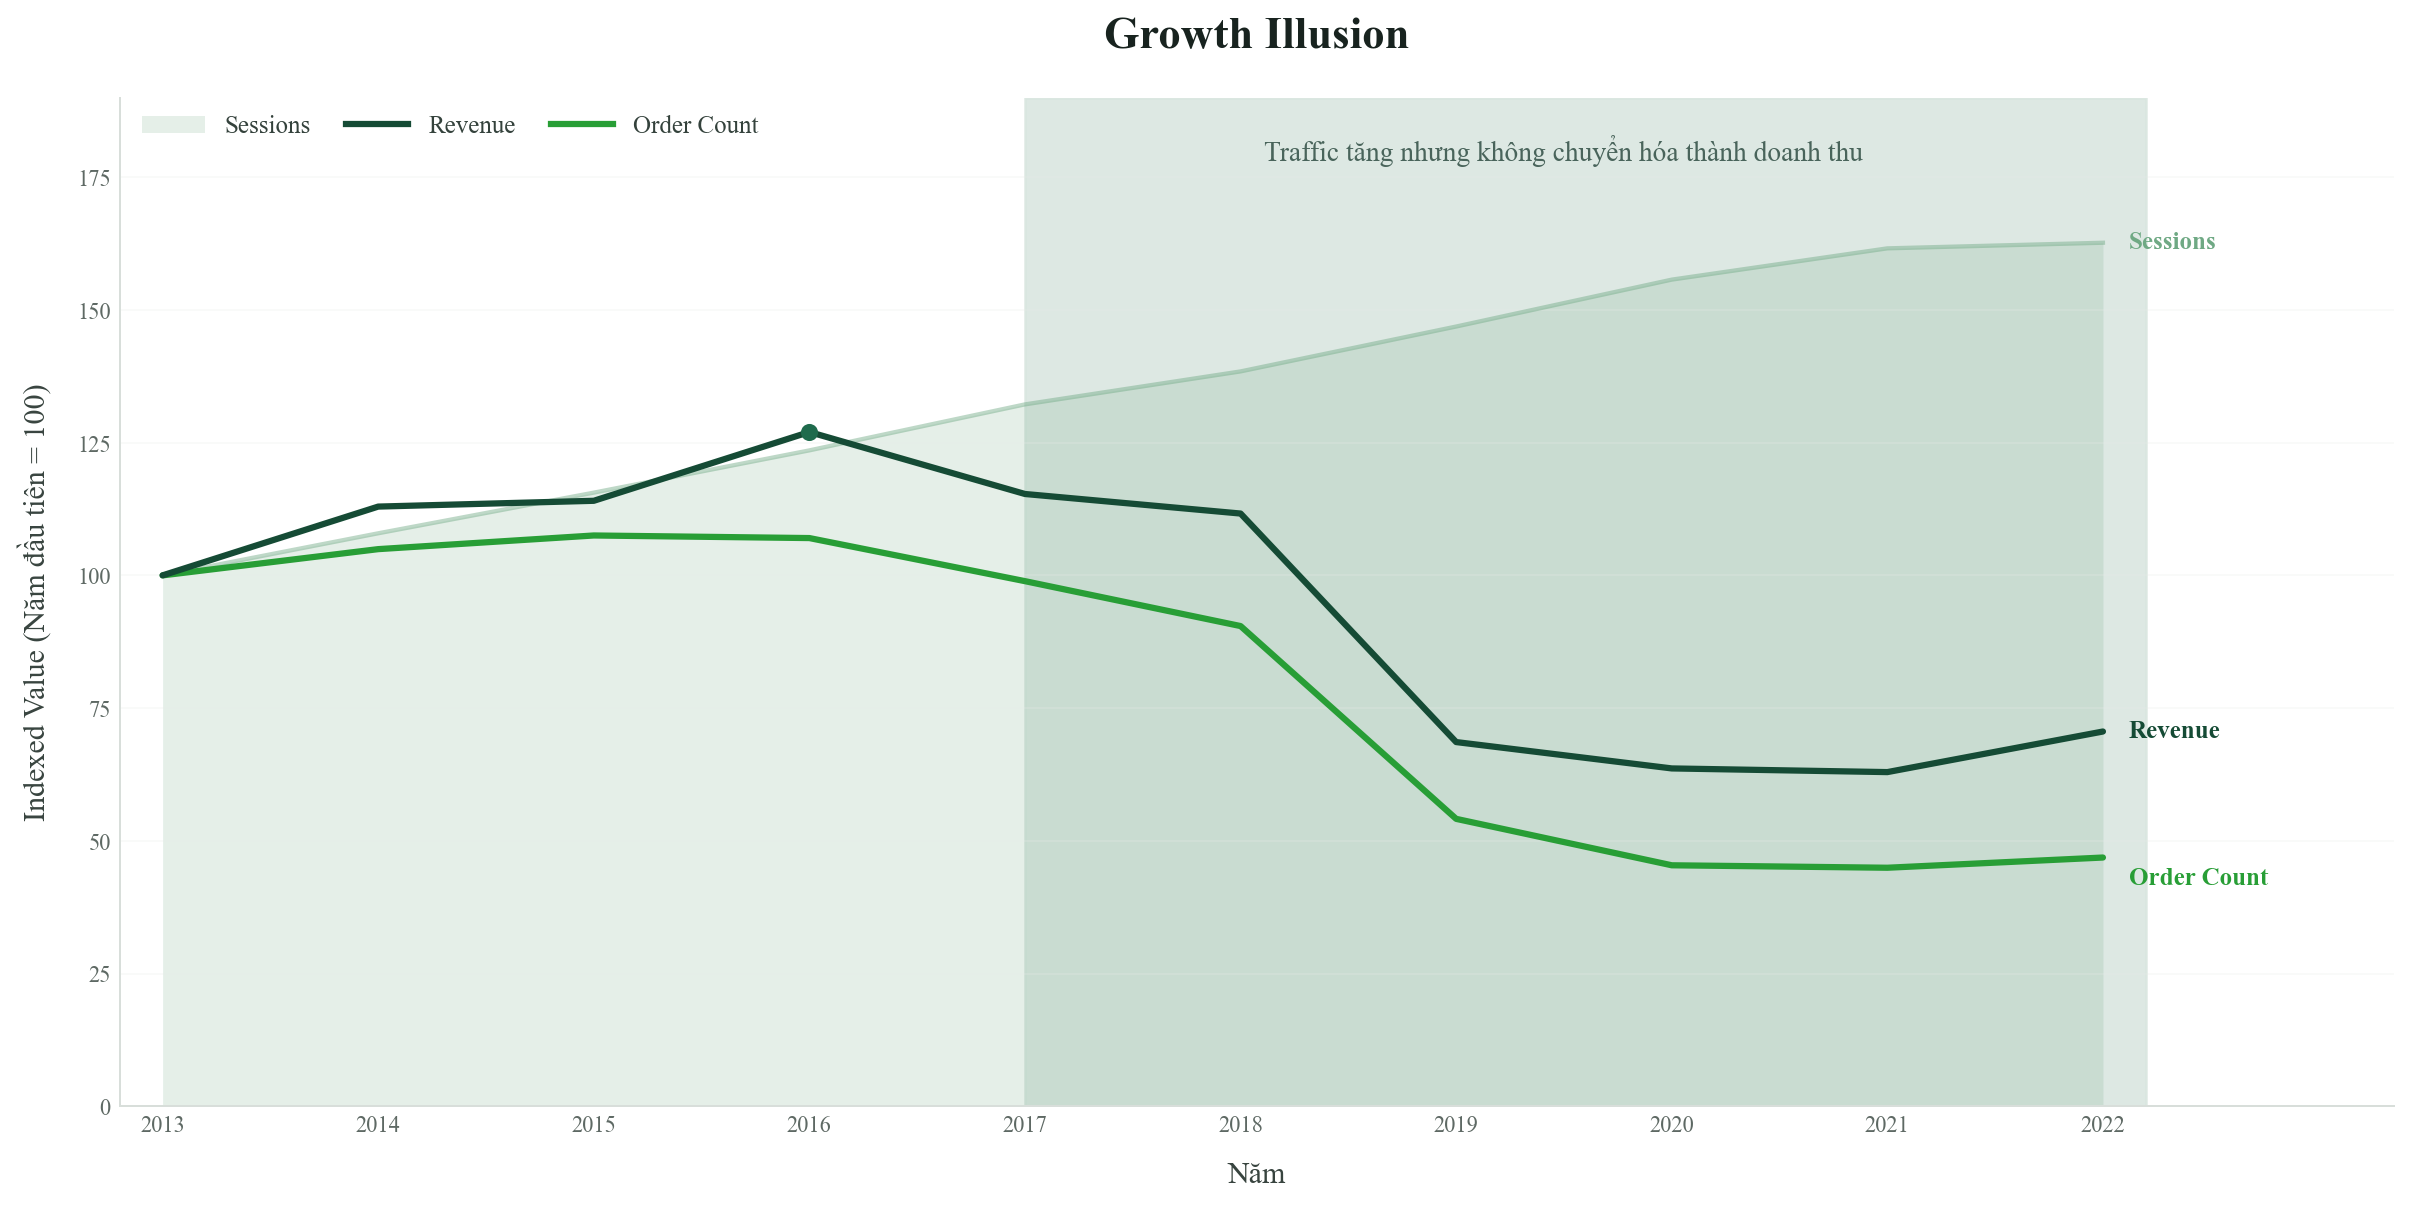

,Year,sessions,revenue,orders,sessions_index,revenue_index,orders_index
0,2013,6801940,"1,657,169,417.2700",76849,100.0000,100.0000,100.0000
1,2014,7340960,"1,871,845,882.8000",80645,107.9245,112.9544,104.9396
2,2015,7861938,"1,889,933,826.9200",82622,115.5838,114.0459,107.5121
3,2016,8403399,"2,104,640,677.5400",82247,123.5442,127.0021,107.0242
4,2017,8992602,"1,911,164,325.2800",76010,132.2064,115.3270,98.9082
5,2018,9415085,"1,850,122,456.0800",69510,138.4176,111.6435,90.4501
6,2019,9990148,"1,136,801,441.5100",41601,146.8720,68.5990,54.1334
7,2020,10591082,"1,054,512,158.7900",34881,155.7068,63.6333,45.3890
8,2021,10991725,"1,043,039,819.6300",34525,161.5969,62.9410,44.9258
9,2022,11063658,"1,169,748,831.6900",36004,162.6544,70.5872,46.8503


In [84]:

# Executive storytelling hook: Traffic growth vs monetization decline
# growth_illusion_traffic_revenue_orders_exec
from pathlib import Path
from tkinter import font
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

DATA_DIR = Path('datathon-2026-round-1')
if not DATA_DIR.exists():
    DATA_DIR = Path('ai_eda/datathon-2026-round-1')

OUTPUT_DIR = Path('report_visuals')
if not OUTPUT_DIR.exists():
    OUTPUT_DIR = Path('ai_eda/report_visuals')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

traffic = pd.read_csv(DATA_DIR / 'web_traffic.csv', parse_dates=['date'])
sales = pd.read_csv(DATA_DIR / 'sales.csv', parse_dates=['Date'])
orders = pd.read_csv(DATA_DIR / 'orders.csv', parse_dates=['order_date'])

sessions_annual = (
    traffic.assign(Year=traffic['date'].dt.year)
    .groupby('Year', as_index=False)['sessions']
    .sum()
)
revenue_annual = (
    sales.assign(Year=sales['Date'].dt.year)
    .groupby('Year', as_index=False)['Revenue']
    .sum()
    .rename(columns={'Revenue': 'revenue'})
)
orders_annual = (
    orders.assign(Year=orders['order_date'].dt.year)
    .groupby('Year', as_index=False)['order_id']
    .nunique()
    .rename(columns={'order_id': 'orders'})
)

annual = (
    pd.DataFrame({'Year': range(2013, 2023)})
    .merge(sessions_annual, on='Year', how='left')
    .merge(revenue_annual, on='Year', how='left')
    .merge(orders_annual, on='Year', how='left')
)

# Normalize each metric to its first available year. Sessions start in 2013 in the provided traffic file.
base_year = 2013
for metric in ['sessions', 'revenue', 'orders']:
    base_value = annual.loc[annual['Year'] == base_year, metric].values[0]
    annual[f'{metric}_index'] = (annual[metric] / base_value) * 100

annual.to_csv(OUTPUT_DIR / 'growth_illusion_indexed_metrics_exec.csv', index=False)

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 10,
    'axes.titlesize': 18,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

fig, ax = plt.subplots(figsize=(13.5, 7.4), dpi=180)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Story region: monetization divergence period.
ax.axvspan(2017, 2022.2, color="#D8E5DF", alpha=0.85, zorder=0)
ax.text(
    2019.5, 180,
    'Traffic tăng nhưng không chuyển hóa thành doanh thu',
    ha='center', va='center', fontsize=11, color='#49645B'
)

x = annual['Year'].to_numpy()
sessions_idx = annual['sessions_index'].to_numpy(dtype=float)
revenue_idx = annual['revenue_index'].to_numpy(dtype=float)
orders_idx = annual['orders_index'].to_numpy(dtype=float)

# Background context: sessions area should support, not dominate.
ax.fill_between(
    x, sessions_idx, 0,
    where=~np.isnan(sessions_idx),
    interpolate=True,
    color="#6FA984", alpha=0.18, linewidth=0, zorder=1,
)
ax.plot(x, sessions_idx, color="#6FA984", linewidth=1.7, alpha=0.45, zorder=2)

# Main KPI emphasis.
ax.plot(
    x, revenue_idx,
    color="#154B35", linewidth=2.5, solid_capstyle='round', zorder=4,
)
ax.plot(
    x, orders_idx,
    color="#289E36", linewidth=2.5, solid_capstyle='round', zorder=3,
)

# Endpoint labels for executive readability.
label_specs = [
    ('Sessions', sessions_idx, "#6FA984", 0),
    ('Revenue', revenue_idx, "#154B35", 0),
    ('Order Count', orders_idx, "#289E36", -4),
]
for label, series, color, dy in label_specs:
    valid = np.where(~np.isnan(series))[0]
    if len(valid):
        i = valid[-1]
        ax.text(x[i] + 0.12, series[i] + dy, label, color=color, fontsize=10, va='center', fontweight='bold')

# Minimal, high-signal annotations.
peak_year = int(annual.loc[annual['revenue_index'].idxmax(), 'Year'])
peak_revenue_idx = float(annual['revenue_index'].max())
ax.scatter([peak_year], [peak_revenue_idx], s=34, color='#1F6B4D', zorder=5)

# ax.annotate(
#     'Sessions tiep tuc tang manh\ntrong khi Revenue va Orders\nduy tri o muc thap',
#     xy=(2021.6, 158), xytext=(2017.65, 126),
#     ha='left', va='center', fontsize=9.2, color='#2B3A33',
#     bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#D7DDD9', linewidth=0.8),
#     arrowprops=dict(arrowstyle='->', color='#7A8580', linewidth=0.9, shrinkA=3, shrinkB=5),
#     zorder=6,
# )

# ax.annotate(
#     'Hiệu quả chuyển đổi giảm rõ rệt từ 2017',
#     xy=(2017, revenue_idx[annual.index[annual['Year'].eq(2017)][0]]), xytext=(2018.2, 92),
#     ha='left', va='center', fontsize=8.8, color='#4A5550',
#     bbox=dict(boxstyle='round,pad=0.30', facecolor='white', edgecolor='#E1E6E3', linewidth=0.7),
#     arrowprops=dict(arrowstyle='->', color='#8A948F', linewidth=0.8, shrinkA=3, shrinkB=5),
#     zorder=6
# )

ax.set_title(
    'Growth Illusion',
    loc='center', fontdict={'family': 'Times New Roman', 'fontweight': 'bold', 'color': '#18231F'}, pad=20
)
# ax.text(
#     0, 1.035,
#     'Sau năm 2017, các chỉ số acquisition tiếp tục tăng trong khi hiệu quả monetization suy giảm rõ rệt.',
#     transform=ax.transAxes, ha='left', va='bottom', fontsize=11, color='#5B6661'
# )

ax.set_ylabel('Indexed Value (Năm đầu tiên = 100)', color='#38443F', fontsize=12, labelpad=10)
ax.set_xlabel('Năm', color='#38443F', fontsize=12, labelpad=10)
ax.set_xlim(2012.8, 2023.35)
y_max = np.nanmax([sessions_idx, revenue_idx, orders_idx])
ax.set_ylim(0, max(190, np.ceil((y_max + 15) / 10) * 10))
ax.set_xticks(range(2013, 2023))
ax.yaxis.set_major_locator(mticker.MultipleLocator(25))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))

ax.grid(axis='y', color='#E8ECE9', linewidth=0.75)
ax.grid(axis='x', visible=False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#D8DEDA')
    ax.spines[spine].set_linewidth(0.8)
ax.tick_params(axis='both', colors='#5E6964', length=0)

legend_handles = [
    Patch(facecolor="#6FA984", edgecolor='none', alpha=0.18, label='Sessions'),
    Line2D([0], [0], color="#154B35", linewidth=2.5, label='Revenue'),
    Line2D([0], [0], color="#289E36", linewidth=2.5, label='Order Count'),
]
ax.legend(
    handles=legend_handles, loc='upper left', bbox_to_anchor=(0.0, 1.005),
    frameon=False, ncol=3, handlelength=2.5, columnspacing=1.4, labelcolor='#34423C'
)

# ax.text(
#     0, -0.12,
#     'Note: Indexed to the first available non-zero year for each metric. Traffic data starts in 2013; Revenue and Order Count start in 2012.',
#     transform=ax.transAxes, fontsize=8.2, color='#78827D', ha='left'
# )

plt.tight_layout(rect=[0, 0.02, 1, 0.94])
fig.savefig(OUTPUT_DIR / 'growth_illusion_traffic_revenue_orders_exec.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(OUTPUT_DIR / 'growth_illusion_traffic_revenue_orders_exec.svg', bbox_inches='tight', facecolor='white')
plt.show()

display(annual)
